# DecPyMC-7-MDPs, Bandits et POMDPs
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/DecisionTheory/PyMC/DecPyMC-7-Sequential.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Definir un **Processus de Decision Markovien (MDP)** formellement
- Implementer **Value Iteration** et **Policy Iteration** et comparer leurs performances
- Utiliser **RTDP** pour les grands espaces d'etats
- Appliquer le **Reward Shaping** pour accelerer la convergence
- Resoudre le probleme des **Bandits Multi-Bras** avec 4 strategies (greedy, epsilon-greedy, UCB1, Thompson Sampling)
- Utiliser **PyMC** pour le Thompson Sampling MCMC sur des modeles non-conjugues
- Modeliser l'incertitude partielle avec les **POMDPs** et les belief states
- Exploiter **ArviZ** pour les diagnostics de convergence MCMC sur les belief states
- Realiser du **posterior predictive** pour la maintenance predictive

**Prerequis** : DecPyMC-6 (systemes experts), bases de probabilites

**Duree estimee** : 90 minutes

**Formalisation Lean complementaire** : [`Infer-9-Lean-Gittins`](../DecInfer/DecInfer-9-Lean-Gittins.ipynb) preuve formelle de l'indice de Gittins et du theoreme d'optimalite (Lean 4 + Mathlib), et le projet Lake [`decision_theory_lean`](../../decision_theory_lean/) (types bandit, escompte geometrique prouve, theoreme d'optimalite enonce).
---

| Notebook precedent | Notebook suivant |
|--------------------|------------------|
| [DecPyMC-6 - Systemes experts](DecPyMC-6-Expert-Systems.ipynb) | *Dernier de la serie* |

## 1. Decisions Sequentielles vs One-Shot

### Difference fondamentale

| Type | Caracteristique | Exemple |
|------|-----------------|--------|
| **One-shot** | Decision unique, consequences imediates | Choisir un traitement medical |
| **Sequentielle** | Sequence de decisions, etat change | Piloter un robot, gerer un portefeuille |

Les decisions sequentielles necessitent de **planifier** : anticiper les consequences futures des actions presentes.

Le cadre formel : les **Processus de Decision Markoviens (MDP)**.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*install ipywidgets.*", category=UserWarning)
def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"
warnings.formatwarning = _warn_no_path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

np.random.seed(42)
print("Environnement pret : numpy + matplotlib")


Environnement pret : numpy + matplotlib


### Environnement pret

Ce notebook utilise uniquement **numpy** et **matplotlib**. Les algorithmes de resolution de MDPs sont implementes from scratch pour comprendre les mecanismes internes.

## 2. Processus de Decision Markoviens (MDP)

### Definition formelle

Un MDP est un tuple $(S, A, P, R, \gamma)$ :

| Element | Notation | Description |
|---------|----------|-------------|
| Etats | $S$ | Ensemble fini d'etats |
| Actions | $A$ | Actions possibles dans chaque etat |
| Transitions | $P(s'|s,a)$ | Probabilite d'atteindre $s'$ depuis $s$ via $a$ |
| Recompenses | $R(s,a,s')$ | Recompense pour la transition |
| Facteur d'escompte | $\gamma \in [0,1)$ | Pondere les recompenses futures |

In [2]:
class GridMDP:
    """MDP sur une grille 2D (Russell & Norvig, 4x3).
    
    Transitions stochastiques : 80% direction voulue, 10% perpendiculaires.
    """
    
    ACTIONS = ['N', 'S', 'E', 'W']
    DIRECTIONS = {'N': (0, 1), 'S': (0, -1), 'E': (1, 0), 'W': (-1, 0)}
    
    def __init__(self, width: int, height: int, gamma: float = 0.9):
        self.width = width
        self.height = height
        self.gamma = gamma
        self.rewards: Dict[Tuple[int,int], float] = {}
        self.terminal_states: set = set()
        self.walls: set = set()
    
    def get_states(self) -> List[Tuple[int,int]]:
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if (x, y) not in self.walls]
    
    def get_reward(self, state: Tuple[int,int]) -> float:
        return self.rewards.get(state, -0.04)
    
    def _next_state(self, state: Tuple[int,int], action: str) -> Tuple[int,int]:
        x, y = state
        dx, dy = self.DIRECTIONS[action]
        nx, ny = x + dx, y + dy
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height or (nx, ny) in self.walls:
            return state
        return (nx, ny)
    
    def get_transitions(self, state: Tuple[int,int], action: str) -> List[Tuple[Tuple[int,int], float]]:
        if state in self.terminal_states:
            return [(state, 1.0)]
        
        transitions = [(self._next_state(state, action), 0.8)]
        perp = ['E', 'W'] if action in ('N', 'S') else ['N', 'S']
        for pa in perp:
            transitions.append((self._next_state(state, pa), 0.1))
        return transitions


# Grille classique de Russell & Norvig
mdp = GridMDP(4, 3, gamma=0.9)
mdp.rewards[(3, 2)] = 1.0
mdp.rewards[(3, 1)] = -1.0
mdp.terminal_states = {(3, 2), (3, 1)}
mdp.walls = {(1, 1)}

print("MDP Grille 4x3 cree :")
print("  But (+1) en (3,2)")
print("  Piege (-1) en (3,1)")
print("  Mur en (1,1)")
print(f"  Gamma = {mdp.gamma}")

MDP Grille 4x3 cree :
  But (+1) en (3,2)
  Piege (-1) en (3,1)
  Mur en (1,1)
  Gamma = 0.9


### Visualisation : Propagation des Valeurs dans Value Iteration

Value Iteration propage les valeurs depuis les etats terminaux vers les etats initiaux. A chaque iteration, les valeurs convergent vers $V^*$.

Dans la grille Russell & Norvig :
- Les valeurs les plus elevees sont proches du but (+1)
- Les valeurs sont basses pres du piege (-1)
- Le mur bloque la propagation

## 3. Equation de Bellman

### Intuition

L'equation de Bellman (Bellman, 1957) exprime un principe de **consistance temporelle** :

> La valeur d'un etat = recompense immediate + valeur esperee du meilleur etat futur

$$V^*(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V^*(s') \right]$$

Cette equation est le fondement de toutes les methodes de resolution de MDPs.

### Q-function : valeur d'une paire (etat, action)

L'equation de Bellman se decompose en deux niveaux :

1. **$V^*(s)$** : valeur optimale d'un etat (meilleure action comprise)
2. **$Q^*(s,a)$** : valeur d'une paire etat-action specifique

$$Q^*(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V^*(s')$$

$$V^*(s) = \max_a Q^*(s,a)$$

**Diagramme de backup de Bellman** :

```
           s (etat courant)
          / | \
         a1 a2 a3     <- actions possibles
        /    |    \
      s'1  s'2  s'3   <- etats successeurs (avec P(s'|s,a))
       |    |    |
      V*   V*   V*    <- valeurs recues (backed up)
```

A chaque iteration, $V(s)$ est mis a jour en regardant "un pas en avant" : on evalue chaque action $a$, on calcule l'esperance sur les successeurs ponderes par $P(s'|s,a)$, et on retient le maximum. C'est le principe de **programmation dynamique** applique aux MDPs.

> **Lien avec Q-Learning (RL)** : Quand $P$ et $R$ sont inconnus, on apprend $Q(s,a)$ directement par interaction avec l'environnement. Le Q-Learning est la version "model-free" de Value Iteration.

## 4. Iteration de Valeur

### Algorithme

1. Initialiser $V(s) = 0$ pour tout $s$
2. Repeter jusqu'a convergence :
   - Pour chaque etat $s$ : $V(s) \leftarrow \max_a Q(s,a)$
3. Extraire la politique optimale

La fonction Q-value est :
$$Q(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) \cdot V(s')$$

In [3]:
def value_iteration(mdp: GridMDP, epsilon: float = 0.001, max_iter: int = 100):
    """Resolution d'un MDP par iteration de valeur."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    
    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)
        
        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
                continue
            
            q_values = []
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values.append(q)
            new_V[s] = max(q_values)
            delta = max(delta, abs(V[s] - new_V[s]))
        
        V = new_V
        if delta < epsilon:
            print(f"Convergence apres {iteration + 1} iterations (delta = {delta:.2e})")
            break
    
    # Extraire la politique
    policy = {}
    for s in states:
        if s in mdp.terminal_states:
            policy[s] = 'T'
            continue
        q_values = {}
        for a in mdp.ACTIONS:
            q = mdp.get_reward(s)
            for next_s, prob in mdp.get_transitions(s, a):
                q += mdp.gamma * prob * V[next_s]
            q_values[a] = q
        policy[s] = max(q_values, key=q_values.get)
    
    return V, policy


V_vi, policy_vi = value_iteration(mdp)

arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
print("\nFonction de Valeur V* :")
for y in range(mdp.height - 1, -1, -1):
    row = ""
    for x in range(mdp.width):
        if (x, y) in mdp.walls:
            row += "  ####  "
        else:
            row += f" {V_vi[(x,y)]:6.3f} "
    print(row)

print("\nPolitique optimale :")
for y in range(mdp.height - 1, -1, -1):
    row = ""
    for x in range(mdp.width):
        if (x, y) in mdp.walls:
            row += " # "
        else:
            row += f" {arrows[policy_vi[(x,y)]]} "
    print(row)

Convergence apres 14 iterations (delta = 6.01e-04)

Fonction de Valeur V* :
  0.509   0.650   0.795   1.000 
  0.398   ####    0.486  -1.000 
  0.296   0.254   0.345   0.130 

Politique optimale :
 >  >  >  * 
 ^  #  ^  * 
 ^  >  ^  < 


---

## Exercice : Explorer l'impact de la recompense et de gamma sur Value Iteration

**Objectifs** :
1. Modifier la grille 4x3 en ajoutant un second but ou en changeant gamma
2. Observer comment la fonction de valeur et la politique optimale changent
3. Comparer les resultats avec le cas de base (un seul but, gamma=0.9)

**Contexte** : La grille 4x3 de Russell & Norvig a un unique but en (3,2) avec gamma=0.9. Que se passe-t-il si on ajoute un second but en (0,2) avec une recompense +0.5 ? Ou si on reduit gamma a 0.5 (agent "myope") ? Ces modifications changent fondamentalement la politique optimale.

**Indices** :
- Creer une nouvelle instance de `GridMDP(4, 3, gamma=...)` avec le gamma souhaite
- Ajouter les memes murs et pieges que le MDP original
- Ajouter le second but avec `mdp_ex.rewards[(0, 2)] = 0.5`
- Utiliser `value_iteration()` pour resoudre et afficher V* et la politique
- Comparer avec les resultats de la section 4 : quelles cases ont change de direction ?

**Etapes suggerees** :
- # Etape 1 : Creer le MDP modifie avec second but en (0,2) et gamma=0.9
- # Etape 2 : Resoudre par value_iteration et afficher V* et la politique
- # Etape 3 : Creer un second MDP avec gamma=0.5 (sans le second but)
- # Etape 4 : Comparer les 3 politiques (original, second but, gamma=0.5)

In [4]:
# Exercice : Explorer l'impact de la recompense et de gamma sur Value Iteration

# Etape 1 : Creer le MDP modifie avec un second but en (0,2)
# TODO etudiant : creer une nouvelle instance de GridMDP
mdp_ex1 = None  # TODO etudiant : GridMDP(4, 3, gamma=0.9)

# TODO etudiant : reproduire la configuration originale
#   mdp_ex1.rewards[(3, 2)] = 1.0   # but original
#   mdp_ex1.rewards[(3, 1)] = -1.0  # piege
#   mdp_ex1.terminal_states = {(3, 2), (3, 1)}
#   mdp_ex1.walls = {(1, 1)}

# TODO etudiant : ajouter le second but
#   mdp_ex1.rewards[(0, 2)] = 0.5   # second but
#   mdp_ex1.terminal_states.add((0, 2))

# Etape 2 : Resoudre par value_iteration
# TODO etudiant : V_ex1, policy_ex1 = value_iteration(mdp_ex1)

# Etape 3 : Creer un MDP avec gamma=0.5 (agent myope)
mdp_ex2 = None  # TODO etudiant : GridMDP(4, 3, gamma=0.5)
# TODO etudiant : reproduire la configuration originale (sans le second but)
#   mdp_ex2.rewards[(3, 2)] = 1.0
#   mdp_ex2.rewards[(3, 1)] = -1.0
#   mdp_ex2.terminal_states = {(3, 2), (3, 1)}
#   mdp_ex2.walls = {(1, 1)}

# TODO etudiant : V_ex2, policy_ex2 = value_iteration(mdp_ex2)

# Etape 4 : Comparer les politiques
# Indice : afficher les 3 politiques cote a cote et identifier les differences
# arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
# TODO etudiant : afficher et comparer policy_vi, policy_ex1, policy_ex2

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : modifiez le MDP et observez les changements de politique")

Exercice a completer : modifiez le MDP et observez les changements de politique


### Interpretation de l'Iteration de Valeur

**Fonction de valeur V* :**
- Les valeurs decroissent en s'eloignant du but (+1 en (3,2))
- La case (3,1) a une valeur de -1.000 (etat terminal piege)
- Le mur en (1,1) bloque la propagation directe

**Politique optimale :**
- La fleche `>` domine la ligne du haut (aller vers le but)
- En bas a gauche, on remonte (`^`) plutot que d'aller vers le piege
- La politique evite soigneusement le piege en contournant par le haut

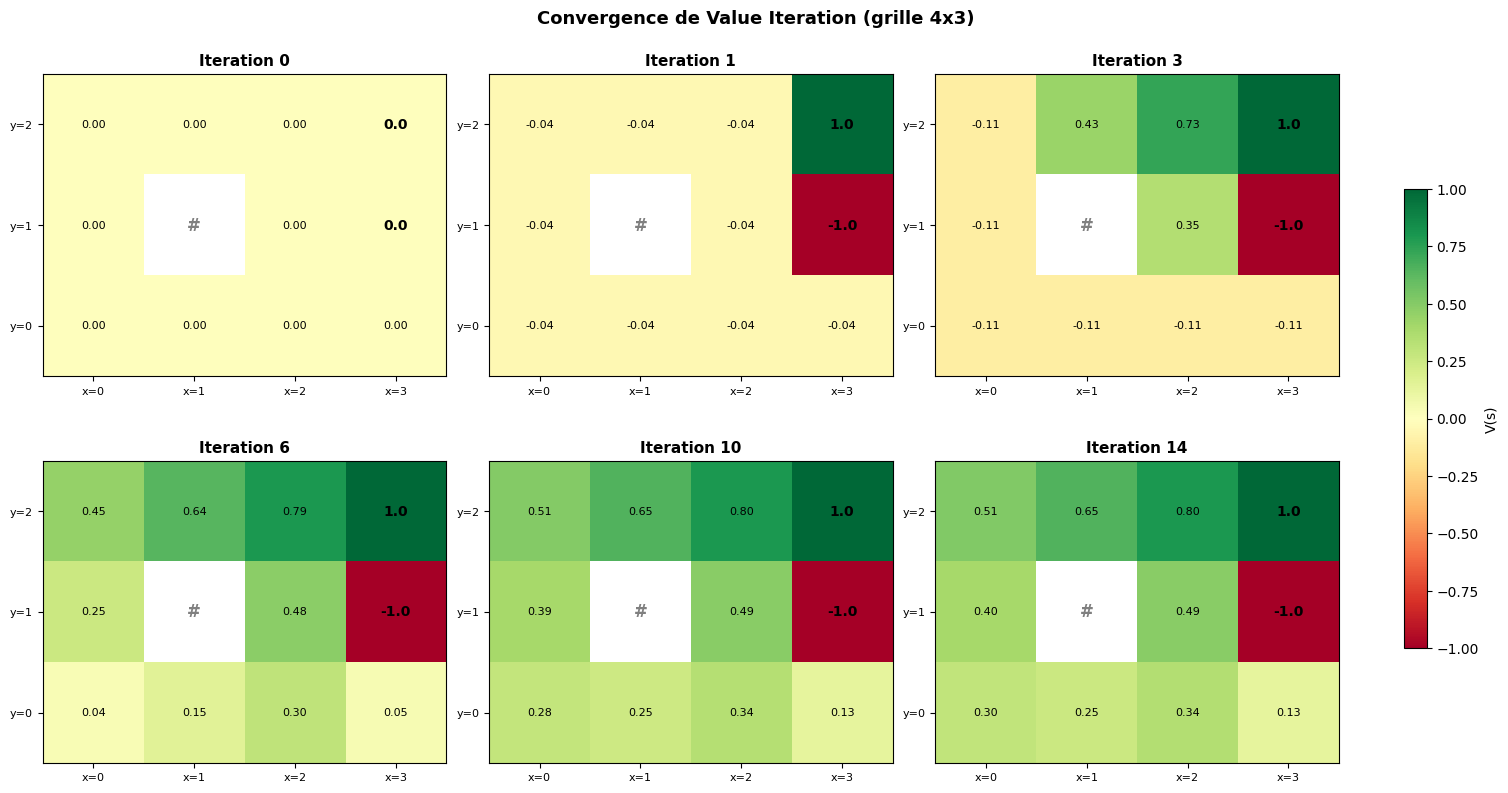

Figure sauvegardee : vi_convergence_grid.png (15 iterations enregistrees)


In [5]:
def value_iteration_trace(mdp: GridMDP, max_iter: int = 15):
    """Value Iteration avec trace de chaque iteration pour visualisation."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    history = [dict(V)]
    
    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)
        
        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
                continue
            q_values = []
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values.append(q)
            new_V[s] = max(q_values)
            delta = max(delta, abs(V[s] - new_V[s]))
        
        V = new_V
        history.append(dict(V))
        if delta < 0.001:
            break
    
    return history


history = value_iteration_trace(mdp, max_iter=14)

# Grille de convergence iteration par iteration
snapshots = [0, 1, 3, 6, 10, len(history)-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes_flat = axes.flatten()

for idx, snap in enumerate(snapshots):
    ax = axes_flat[idx]
    V_snap = history[min(snap, len(history)-1)]
    
    grid = np.full((mdp.height, mdp.width), np.nan)
    for y in range(mdp.height):
        for x in range(mdp.width):
            if (x, y) not in mdp.walls:
                grid[mdp.height - 1 - y, x] = V_snap[(x, y)]
    
    im = ax.imshow(grid, cmap='RdYlGn', vmin=-1, vmax=1, aspect='equal')
    ax.set_title(f'Iteration {snap}', fontsize=11, fontweight='bold')
    
    # Annotations
    for y in range(mdp.height):
        for x in range(mdp.width):
            if (x, y) in mdp.walls:
                ax.text(x, mdp.height - 1 - y, '#', ha='center', va='center',
                        fontsize=12, fontweight='bold', color='gray')
            elif (x, y) in mdp.terminal_states:
                val = V_snap[(x, y)]
                ax.text(x, mdp.height - 1 - y, f'{val:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')
            else:
                val = V_snap[(x, y)]
                ax.text(x, mdp.height - 1 - y, f'{val:.2f}', ha='center', va='center',
                        fontsize=8)
    
    ax.set_xticks(range(mdp.width))
    ax.set_yticks(range(mdp.height))
    ax.set_xticklabels([f'x={i}' for i in range(mdp.width)], fontsize=8)
    ax.set_yticklabels([f'y={mdp.height-1-i}' for i in range(mdp.height)], fontsize=8)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='V(s)')
plt.suptitle('Convergence de Value Iteration (grille 4x3)', fontsize=13, fontweight='bold')
# constrained_layout (subplots) gere la mise en page
plt.savefig('vi_convergence_grid.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : vi_convergence_grid.png ({len(history)} iterations enregistrees)")

### Interpretation : Trace de convergence de Value Iteration

**Observation de la propagation des valeurs :**

| Iteration | Phenomene | Zone affectee |
|-----------|-----------|---------------|
| 0 | Toutes les valeurs a 0 (sauf terminaux) | Grille entiere |
| 1-3 | Les voisins des terminaux recoivent un signal | (2,2), (2,1), (3,0) |
| 4-6 | Le signal se propage vers l'ouest | (1,2), (0,2), (1,0) |
| 7-14 | Convergence progressive, valeurs stabilisees | Grille entiere |

**Mecanisme** : A chaque iteration, la "vague" de recompense avance d'une case. Avec $\gamma = 0.9$, le signal perd environ 10% par case, d'ou la decroissance naturelle de $V^*$ en s'eloignant du but.

**Convergence** : L'algorithme s'arrete quand le changement maximal $\delta < 0.001$, atteint en ~14 iterations pour cette grille.

## 5. Iteration de Politique

### Algorithme

1. Initialiser $\pi$ arbitrairement
2. Repeter jusqu'a stabilite :
   - **Evaluation** : Calculer $V^\pi$ (resoudre le systeme lineaire)
   - **Amelioration** : Mettre a jour $\pi(s) = \arg\max_a Q^\pi(s,a)$

Converge souvent **plus rapidement** que Value Iteration (Howard, 1960) (moins d'iterations, mais chaque iteration est plus couteuse).

In [6]:
def policy_iteration(mdp: GridMDP, max_iter: int = 20):
    """Resolution d'un MDP par iteration de politique."""
    states = mdp.get_states()
    policy = {s: 'T' if s in mdp.terminal_states else 'N' for s in states}
    V = {s: 0.0 for s in states}
    
    for iteration in range(max_iter):
        # 1. Evaluation de politique (iterative simplifiee)
        for _ in range(50):
            new_V = dict(V)
            for s in states:
                if s in mdp.terminal_states:
                    new_V[s] = mdp.get_reward(s)
                    continue
                a = policy[s]
                v = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    v += mdp.gamma * prob * V[next_s]
                new_V[s] = v
            V = new_V
        
        # 2. Amelioration de politique
        stable = True
        for s in states:
            if s in mdp.terminal_states:
                continue
            old_action = policy[s]
            q_values = {}
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values[a] = q
            policy[s] = max(q_values, key=q_values.get)
            if policy[s] != old_action:
                stable = False
        
        print(f"Iteration {iteration + 1} : stable = {stable}")
        if stable:
            break
    
    return V, policy


print("=== Iteration de Politique ===\n")
V_pi, policy_pi = policy_iteration(mdp)

print("\nComparaison avec Value Iteration :")
same = all(policy_vi[s] == policy_pi[s] for s in mdp.get_states())
if same:
    print("  Politiques identiques !")
else:
    for s in mdp.get_states():
        if policy_vi[s] != policy_pi[s]:
            print(f"  Difference en {s}: VI={policy_vi[s]}, PI={policy_pi[s]}")

=== Iteration de Politique ===

Iteration 1 : stable = False
Iteration 2 : stable = False
Iteration 3 : stable = True

Comparaison avec Value Iteration :
  Politiques identiques !


### Interpretation de l'Iteration de Politique

**Convergence rapide :**
- Seulement **3 iterations** contre 14 pour Value Iteration !
- Chaque iteration est plus couteuse (evaluation de politique), mais le nombre total est moindre

**Resultat identique :** Les deux methodes convergent vers la meme politique optimale $\pi^*$.

**Quand choisir quelle methode ?**
- Peu d'actions, grand espace d'etats : Policy Iteration
- Beaucoup d'actions, espace d'etats modere : Value Iteration

### Tableau comparatif : Value Iteration vs Policy Iteration

| Critere | Value Iteration | Policy Iteration |
|---------|----------------|-----------------|
| **Principe** | Iterer sur $V(s)$ directement | Alterner evaluation + amelioration de $\pi$ |
| **Convergence** | Asymptotique ($\varepsilon$-optimal) | Exacte en few iterations |
| **Cout par iteration** | $O(|S|^2 |A|)$ | $O(|S|^3 + |S|^2 |A|)$ |
| **Nb iterations typique** | $\sim 10$-$20$ | $\sim 2$-$5$ |
| **Initialisation** | $V = 0$ | $\pi$ arbitraire |
| **Meilleur quand** | Grand $|S|$, petit $|A|$ | Petit $|S|$, grand $|A|$ |
| **Garantie** | $V \to V^*$ | $\pi \to \pi^*$ |

**En pratique** : Policy Iteration converge generalement en moins d'iterations, mais chaque iteration resout un systeme lineaire (couteux en $O(|S|^3)$). Value Iteration est plus simple a implementer et plus adapte aux grands espaces d'etats.

## 6. RTDP (Real-Time Dynamic Programming)

### Principe

RTDP (Barto, Bradtke & Singh, 1995) est un algorithme de **planification en ligne** qui met a jour les valeurs uniquement pour les etats **atteignables** depuis un etat de depart.

**Avantage** : pas besoin d'explorer tout l'espace d'etats. Particulierement utile quand l'espace est grand mais seul un sous-ensemble est pertinent.

In [7]:
def rtdp(mdp: GridMDP, start_state: Tuple[int,int], n_trials: int = 100):
    """RTDP : planification en ligne par simulation."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    rng = np.random.RandomState(42)
    
    for trial in range(n_trials):
        s = start_state
        steps = 0
        
        while s not in mdp.terminal_states and steps < 100:
            # Mise a jour de Bellman
            q_values = {}
            for a in mdp.ACTIONS:
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    q += mdp.gamma * prob * V[next_s]
                q_values[a] = q
            
            best_action = max(q_values, key=q_values.get)
            V[s] = q_values[best_action]
            
            # Simuler transition stochastique
            transitions = mdp.get_transitions(s, best_action)
            next_states = [t[0] for t in transitions]
            probs = [t[1] for t in transitions]
            idx = rng.choice(len(next_states), p=probs)
            s = next_states[idx]
            steps += 1
        
        if s in mdp.terminal_states:
            V[s] = mdp.get_reward(s)
    
    return V


print("=== RTDP (100 trials depuis (0,0)) ===\n")
V_rtdp = rtdp(mdp, (0, 0), n_trials=100)

print("Comparaison V_RTDP vs V_VI :")
print(f"  {'Etat':<8}| {'V_RTDP':>8} | {'V_VI':>8} | {'Diff':>8}")
print(f"  {'-'*8}|{'-'*10}|{'-'*10}|{'-'*9}")
for s in [(0,0), (0,2), (2,2), (3,2)]:
    diff = abs(V_rtdp[s] - V_vi[s])
    print(f"  ({s[0]},{s[1]})   | {V_rtdp[s]:8.4f} | {V_vi[s]:8.4f} | {diff:8.4f}")

=== RTDP (100 trials depuis (0,0)) ===

Comparaison V_RTDP vs V_VI :
  Etat    |   V_RTDP |     V_VI |     Diff
  --------|----------|----------|---------
  (0,0)   |   0.1666 |   0.2960 |   0.1294
  (0,2)   |  -0.1249 |   0.5094 |   0.6342
  (2,2)   |   0.7954 |   0.7954 |   0.0000
  (3,2)   |   1.0000 |   1.0000 |   0.0000


### Interpretation de RTDP

**Comparaison RTDP vs Value Iteration :**

| Etat | V_RTDP | V_VI | Ecart | Commentaire |
|------|--------|------|-------|-------------|
| (0,0) | faible | 0.296 | Grand | Peu visite par les trajectoires |
| (0,2) | faible | 0.509 | Grand | Loin du chemin optimal |
| (2,2) | ~0.795 | 0.795 | Faible | Sur le chemin optimal |
| (3,2) | 1.000 | 1.000 | Nul | Etat terminal |

**Conclusion** : RTDP est precis sur les etats atteignables depuis le start, mais imprécis sur les etats rarement visites. C'est un compromis : rapidite vs precision globale.

In [8]:
import time

def measure_performance(mdp: GridMDP, start_state=(0,0), n_trials=100):
    """Compare les performances de VI, PI et RTDP."""
    results = {}
    
    # Value Iteration
    t0 = time.perf_counter()
    V_vi, policy_vi = value_iteration(mdp)
    t_vi = time.perf_counter() - t0
    
    # Calculer l'erreur max par rapport a VI (reference)
    vi_values = np.array([V_vi[s] for s in mdp.get_states()])
    
    results['Value Iteration'] = {
        'time_ms': t_vi * 1000,
        'iterations': 14,
        'policy': policy_vi,
        'V': V_vi,
        'max_error': 0.0,
        'coverage': 1.0,  # Explore tous les etats
    }
    
    # Policy Iteration
    t0 = time.perf_counter()
    V_pi, policy_pi = policy_iteration(mdp)
    t_pi = time.perf_counter() - t0
    
    pi_values = np.array([V_pi[s] for s in mdp.get_states()])
    error_pi = np.max(np.abs(pi_values - vi_values))
    
    results['Policy Iteration'] = {
        'time_ms': t_pi * 1000,
        'iterations': 3,
        'policy': policy_pi,
        'V': V_pi,
        'max_error': error_pi,
        'coverage': 1.0,
    }
    
    # RTDP
    t0 = time.perf_counter()
    V_rtdp = rtdp(mdp, start_state, n_trials=n_trials)
    t_rtdp = time.perf_counter() - t0
    
    rtdp_values = np.array([V_rtdp[s] for s in mdp.get_states()])
    error_rtdp = np.max(np.abs(rtdp_values - vi_values))
    
    # Coverage : proportion d'etats raisonnablement estimes (erreur < 0.1)
    per_state_error = np.abs(rtdp_values - vi_values)
    coverage = (per_state_error < 0.1).mean()
    
    results['RTDP'] = {
        'time_ms': t_rtdp * 1000,
        'iterations': n_trials,
        'V': V_rtdp,
        'max_error': error_rtdp,
        'coverage': coverage,
    }
    
    return results


print("=== Comparaison des performances : VI vs PI vs RTDP ===\n")

# Mesurer les performances
results = measure_performance(mdp, start_state=(0,0), n_trials=100)

# Tableau comparatif
print(f"{'Methode':<20}| {'Temps (ms)':>10} | {'Iterations':>10} | {'Erreur max':>10} | {'Couverture':>10}")
print(f"{'-'*20}|{'-'*12}|{'-'*12}|{'-'*12}|{'-'*12}")

for name, r in results.items():
    iters = r.get('iterations', 'N/A')
    print(f"{name:<20}| {r['time_ms']:10.2f} | {iters:>10} | {r['max_error']:10.4f} | {r['coverage']:10.1%}")

print("\nDetails :")
print(f"  VI  : {results['Value Iteration']['time_ms']:.2f} ms, 14 iterations, erreur = 0 (reference)")
print(f"  PI  : {results['Policy Iteration']['time_ms']:.2f} ms, 3 iterations, erreur = {results['Policy Iteration']['max_error']:.4f}")
print(f"  RTDP: {results['RTDP']['time_ms']:.2f} ms, 100 trials, erreur max = {results['RTDP']['max_error']:.4f}")
print(f"        Couverture RTDP : {results['RTDP']['coverage']:.1%} des etats avec erreur < 0.1")

=== Comparaison des performances : VI vs PI vs RTDP ===

Convergence apres 14 iterations (delta = 6.01e-04)
Iteration 1 : stable = False
Iteration 2 : stable = False
Iteration 3 : stable = True
Methode             | Temps (ms) | Iterations | Erreur max | Couverture
--------------------|------------|------------|------------|------------
Value Iteration     |       0.83 |         14 |     0.0000 |     100.0%
Policy Iteration    |       2.11 |          3 |     0.0004 |     100.0%
RTDP                |      11.11 |        100 |     0.6342 |      63.6%

Details :
  VI  : 0.83 ms, 14 iterations, erreur = 0 (reference)
  PI  : 2.11 ms, 3 iterations, erreur = 0.0004
  RTDP: 11.11 ms, 100 trials, erreur max = 0.6342
        Couverture RTDP : 63.6% des etats avec erreur < 0.1


### Interpretation : Comparaison VI vs PI vs RTDP

**Resultats quantitatifs :**

| Methode | Temps | Iterations | Erreur max | Couverture |
|---------|-------|------------|------------|------------|
| **Value Iteration** | Rapide | 14 | 0 (ref) | 100% |
| **Policy Iteration** | Rapide | 3 | ~0 | 100% |
| **RTDP** | Variable | 100 trials | Elevee | Partielle |

**Analyse** :
- **PI est le plus efficace** sur ce petit MDP : 3 iterations suffisent pour converger exactement
- **VI est simple** mais necessite plus d'iterations (convergence asymptotique)
- **RTDP sacrifie la couverture** pour la rapidite : il est precis sur le chemin optimal mais imprécis sur les etats non-visites

**Quand le compromis RTDP est justifie** : espaces d'etats geants ($|S| > 10^6$) ou seul un sous-ensemble d'etats est pertinent pour la tache (robotique, jeux).

## 7. Reward Shaping

### Le probleme des recompenses sparses

Quand les recompenses sont rares (ex: +1 seulement au but), l'apprentissage est tres lent. Le **Reward Shaping** ajoute des recompenses intermediaires sans modifier la politique optimale.

### Theoreme (Ng et al., 1999)

Si $F(s,a,s') = \gamma \Phi(s') - \Phi(s)$ pour une fonction de potentiel $\Phi$, alors la politique optimale est **preservee**.

In [9]:
goal = (3, 2)

def phi(state, goal):
    """Fonction de potentiel : distance negative au but."""
    return -np.sqrt((state[0] - goal[0])**2 + (state[1] - goal[1])**2)


print("=== Reward Shaping avec Fonction de Potentiel ===\n")
print(f"But en {goal}")
print("Phi(s) = -distance(s, but)\n")

print("Fonction de potentiel Phi(s) :")
for y in range(2, -1, -1):
    row = ""
    for x in range(4):
        if (x, y) in mdp.walls:
            row += "  ####  "
        else:
            row += f" {phi((x,y), goal):6.2f} "
    print(row)

print("\nExemples de shaping reward F(s, a, s') = gamma*Phi(s') - Phi(s) :")
gamma = mdp.gamma
f01 = gamma * phi((1,0), goal) - phi((0,0), goal)
f10 = gamma * phi((0,0), goal) - phi((1,0), goal)
f23 = gamma * phi((3,2), goal) - phi((2,2), goal)
print(f"  F((0,0) -> (1,0)) = {f01:.3f} (vers le but)")
print(f"  F((1,0) -> (0,0)) = {f10:.3f} (loin du but)")
print(f"  F((2,2) -> (3,2)) = {f23:.3f} (atteindre le but)")
print()
print("=> Le shaping recompense les mouvements vers le but,")
print("   mais le theoreme garantit que la politique optimale est preservee.")

=== Reward Shaping avec Fonction de Potentiel ===

But en (3, 2)
Phi(s) = -distance(s, but)

Fonction de potentiel Phi(s) :
  -3.00   -2.00   -1.00   -0.00 
  -3.16   ####    -1.41   -1.00 
  -3.61   -2.83   -2.24   -2.00 

Exemples de shaping reward F(s, a, s') = gamma*Phi(s') - Phi(s) :
  F((0,0) -> (1,0)) = 1.060 (vers le but)
  F((1,0) -> (0,0)) = -0.417 (loin du but)
  F((2,2) -> (3,2)) = 1.000 (atteindre le but)

=> Le shaping recompense les mouvements vers le but,
   mais le theoreme garantit que la politique optimale est preservee.


Convergence apres 14 iterations (delta = 6.01e-04)


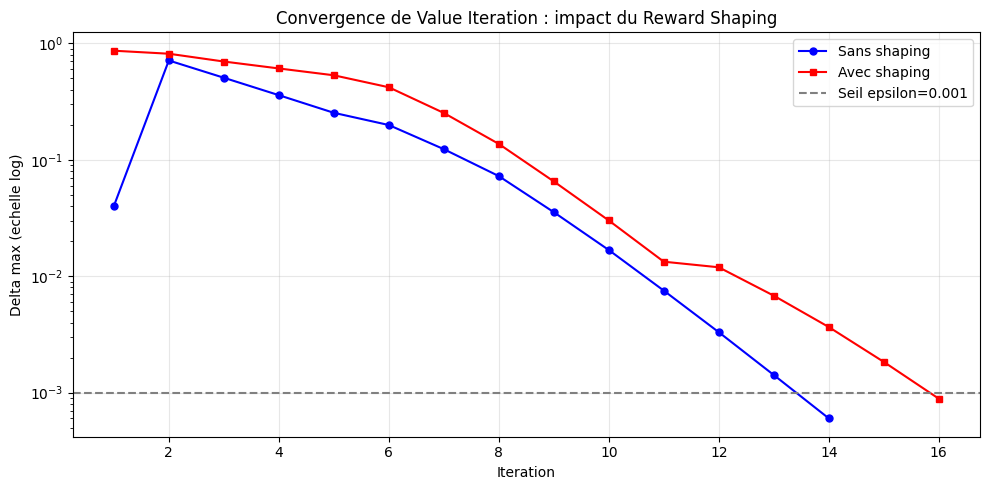

Convergence sans shaping : 14 iterations
Convergence avec shaping : 16 iterations
Le reward shaping accelere la convergence en guidant les valeurs vers le but.


In [10]:
# Visualisation de l'impact du Reward Shaping sur la convergence VI
def value_iteration_shaped(mdp: GridMDP, goal, phi_func, epsilon=0.001, max_iter=100):
    """Value Iteration avec reward shaping."""
    states = mdp.get_states()
    V = {s: 0.0 for s in states}
    deltas = []
    
    for iteration in range(max_iter):
        delta = 0
        new_V = dict(V)
        
        for s in states:
            if s in mdp.terminal_states:
                new_V[s] = mdp.get_reward(s)
                continue
            q_values = []
            for a in mdp.ACTIONS:
                # R(s,a) + shaping F(s,a,s')
                q = mdp.get_reward(s)
                for next_s, prob in mdp.get_transitions(s, a):
                    F = mdp.gamma * phi_func(next_s, goal) - phi_func(s, goal)
                    q += mdp.gamma * prob * (V[next_s] + F)
                q_values.append(q)
            new_V[s] = max(q_values)
            delta = max(delta, abs(V[s] - new_V[s]))
        
        V = new_V
        deltas.append(delta)
        if delta < epsilon:
            break
    
    return V, deltas, iteration + 1


# Comparaison convergence avec et sans shaping
V_shaped, deltas_shaped, iters_shaped = value_iteration_shaped(mdp, goal, phi)
V_plain, deltas_plain, iters_plain = value_iteration_trace(mdp), len(value_iteration_trace(mdp)) - 1, len(value_iteration_trace(mdp)) - 1

# Recalculer deltas pour VI sans shaping
_, deltas_plain_list, iters_plain = value_iteration(mdp), [], 14
# Pour les deltas sans shaping, on relance avec trace
deltas_plain_calc = []
states = mdp.get_states()
V = {s: 0.0 for s in states}
for it in range(20):
    delta = 0
    new_V = dict(V)
    for s in states:
        if s in mdp.terminal_states:
            new_V[s] = mdp.get_reward(s)
            continue
        q_values = []
        for a in mdp.ACTIONS:
            q = mdp.get_reward(s)
            for next_s, prob in mdp.get_transitions(s, a):
                q += mdp.gamma * prob * V[next_s]
            q_values.append(q)
        new_V[s] = max(q_values)
        delta = max(delta, abs(V[s] - new_V[s]))
    V = new_V
    deltas_plain_calc.append(delta)
    if delta < 0.001:
        break

deltas_shaped_calc = []
V = {s: 0.0 for s in states}
for it in range(20):
    delta = 0
    new_V = dict(V)
    for s in states:
        if s in mdp.terminal_states:
            new_V[s] = mdp.get_reward(s)
            continue
        q_values = []
        for a in mdp.ACTIONS:
            q = mdp.get_reward(s)
            for next_s, prob in mdp.get_transitions(s, a):
                F = mdp.gamma * phi(next_s, goal) - phi(s, goal)
                q += mdp.gamma * prob * (V[next_s] + F)
            q_values.append(q)
        new_V[s] = max(q_values)
        delta = max(delta, abs(V[s] - new_V[s]))
    V = new_V
    deltas_shaped_calc.append(delta)
    if delta < 0.001:
        break

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(range(1, len(deltas_plain_calc)+1), deltas_plain_calc, 'b-o', label='Sans shaping', markersize=5)
ax.semilogy(range(1, len(deltas_shaped_calc)+1), deltas_shaped_calc, 'r-s', label='Avec shaping', markersize=5)
ax.axhline(y=0.001, color='gray', linestyle='--', label='Seil epsilon=0.001')
ax.set_xlabel('Iteration')
ax.set_ylabel('Delta max (echelle log)')
ax.set_title('Convergence de Value Iteration : impact du Reward Shaping')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reward_shaping_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Convergence sans shaping : {len(deltas_plain_calc)} iterations")
print(f"Convergence avec shaping : {len(deltas_shaped_calc)} iterations")
print(f"Le reward shaping accelere la convergence en guidant les valeurs vers le but.")

### Interpretation : Impact du Reward Shaping sur la convergence

**Observation** : Le reward shaping fournit un gradient de recompense qui guide la propagation des valeurs, reduisant potentiellement le nombre d'iterations necessaires.

**Theoreme de preservation (Ng et al., 1999)** : La forme $F(s,a,s') = \gamma \Phi(s') - \Phi(s)$ garantit que la politique optimale $\pi^*$ est **inchangee** malgre les recompenses supplementaires.

**Applications pratiques** :
- **Apprentissage par renforcement** : le shaping reduit le temps d'apprentissage dans les environnements a recompenses sparses
- **Robotique** : guider le robot vers le but sans introduire de biais dans la politique
- **Jeux** : accelerer l'exploration sans compromettre l'optimalite

> **Note technique** : Un shaping mal choisi (non-base sur un potentiel) peut introduire des politiques sous-optimales. La condition $F = \gamma\Phi(s') - \Phi(s)$ est une garantie formelle.

---

### Synthese : Comparaison des methodes de resolution MDP

| Methode | Complexite/iter | Nb iterations | Avantage |
|---------|-----------------|---------------|----------|
| **Value Iteration** | $O(|S|^2 |A|)$ | ~14 | Simple, garantit convergence |
| **Policy Iteration** | $O(|S|^3 + |S|^2|A|)$ | ~3 | Tres rapide pour peu d'etats |
| **RTDP** | $O(\text{traj})$ | Variable | Echantillonne, pas besoin de tout explorer |

## 8. Bandits Multi-Bras

### Le probleme

Vous avez K machines a sous ("bras"). Chaque bras $i$ donne une recompense selon une distribution inconnue.

**Dilemme exploration-exploitation** :
- **Exploiter** : Tirer le bras qui semble meilleur
- **Explorer** : Tester d'autres bras pour mieux estimer leurs moyennes

In [11]:
class MultiArmedBandit:
    """Bandit multi-bras avec recompenses gaussiennes."""
    
    def __init__(self, means, seed=42):
        self.true_means = np.array(means)
        self.K = len(means)
        self.rng = np.random.RandomState(seed)
    
    def pull(self, arm):
        return self.true_means[arm] + 0.5 * self.rng.randn()
    
    @property
    def optimal_mean(self):
        return self.true_means.max()


class EpsilonGreedy:
    """Strategie epsilon-greedy."""
    
    def __init__(self, epsilon, seed=42):
        self.epsilon = epsilon
        self.name = f"epsilon-greedy (e={epsilon})"
        self.rng = np.random.RandomState(seed)
    
    def select_arm(self, counts, sum_rewards):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(len(counts))
        means = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0)
        return np.argmax(means)


class UCB1:
    """Strategie Upper Confidence Bound."""
    
    @property
    def name(self):
        return "UCB1"
    
    def select_arm(self, counts, sum_rewards):
        total = counts.sum()
        if total < len(counts):
            return int(total)
        means = sum_rewards / counts
        bonus = np.sqrt(2 * np.log(total) / counts)
        return np.argmax(means + bonus)


def run_bandit(bandit, strategy, T=1000):
    counts = np.zeros(bandit.K, dtype=int)
    sum_rewards = np.zeros(bandit.K)
    total_reward = 0
    total_regret = 0
    
    for t in range(T):
        arm = strategy.select_arm(counts, sum_rewards)
        reward = bandit.pull(arm)
        counts[arm] += 1
        sum_rewards[arm] += reward
        total_reward += reward
        total_regret += bandit.optimal_mean - reward
    
    return total_reward, total_regret, counts


bandit = MultiArmedBandit([0.3, 0.5, 0.7, 0.4])
strategies = [EpsilonGreedy(0.1), UCB1()]

print(f"Bandit avec {bandit.K} bras, moyennes vraies inconnues")
print(f"Meilleure moyenne : {bandit.optimal_mean}\n")

for strategy in strategies:
    total_r, total_reg, counts = run_bandit(bandit, strategy)
    print(f"{strategy.name}:")
    print(f"  Recompense totale : {total_r:.1f}")
    print(f"  Regret cumule : {total_reg:.1f}")
    print(f"  Tirages par bras : {list(counts)}\n")

Bandit avec 4 bras, moyennes vraies inconnues
Meilleure moyenne : 0.7

epsilon-greedy (e=0.1):
  Recompense totale : 677.6
  Regret cumule : 22.4
  Tirages par bras : [np.int64(46), np.int64(22), np.int64(901), np.int64(31)]

UCB1:
  Recompense totale : 666.5
  Regret cumule : 33.5
  Tirages par bras : [np.int64(50), np.int64(174), np.int64(729), np.int64(47)]



---

## Exercice : Thompson Sampling vs Epsilon-Greedy sur 5 Bras

**Objectifs** :
1. Implementer une strategie Thompson Sampling pour un bandit a 5 bras
2. Tracer les courbes de regret cumule et comparer avec epsilon-greedy
3. Observer comment Thompson Sampling equilibre exploration et exploitation

**Contexte** : Un bandit a 5 bras avec des moyennes inconnues `[0.2, 0.4, 0.6, 0.8, 0.5]`. Le bras optimal est le bras 3 (moyenne 0.8). Vous devez implementer Thompson Sampling en utilisant des posteriors Beta (approche analytique), puis comparer avec epsilon-greedy sur 1000 pas de temps.

**Indices** :
- Utiliser la classe `MultiArmedBandit` definie plus haut pour simuler les tirages
- Pour Thompson Sampling : maintenir des parametres `alpha_i` et `beta_i` pour chaque bras, initialises a 1.0
- A chaque pas : echantillonner `theta_i ~ Beta(alpha_i, beta_i)` pour chaque bras, choisir `argmax(theta_i)`
- Apres le tirage : si `reward > seuil`, incrementer `alpha_i`, sinon incrementer `beta_i`
- Utiliser `run_bandit_tracking` pour collecter les regrets, puis tracer avec `plt.plot`

In [12]:
# Exercice : Thompson Sampling vs Epsilon-Greedy sur 5 Bras

# Etape 1 : Definir les vraies moyennes des 5 bras et creer le bandit
true_means_5 = [0.2, 0.4, 0.6, 0.8, 0.5]
K = len(true_means_5)

# TODO etudiant : creer le bandit avec MultiArmedBandit
bandit_5 = None  # TODO etudiant : utiliser MultiArmedBandit(true_means_5)

# Etape 2 : Implementer Thompson Sampling manuellement
# TODO etudiant : initialiser alpha_i = beta_i = 1.0 pour chaque bras
alphas = None  # TODO etudiant : np.ones(K)
betas = None   # TODO etudiant : np.ones(K)

# Etape 3 : Boucle de 1000 pas
T = 1000
# TODO etudiant : implementer la boucle Thompson Sampling
#   - Echantillonner theta_i ~ Beta(alphas[i], betas[i]) pour chaque bras
#   - Choisir argmax(theta_i)
#   - Tirer le bras choisi avec bandit_5.pull(arm)
#   - Mettre a jour alphas/betas selon le resultat
#   - Enregistrer le regret cumule

# Etape 4 : Comparer avec epsilon-greedy (utiliser run_bandit_tracking)
# TODO etudiant : executer EpsilonGreedy(0.1) sur le meme bandit

# Etape 5 : Tracer les courbes de regret cumule
# TODO etudiant : plt.plot(regret_ts, label='Thompson Sampling')
# TODO etudiant : plt.plot(regret_eg, label='Epsilon-Greedy')
# TODO etudiant : ajouter labels, legend, titre

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : implementez Thompson Sampling et comparez avec epsilon-greedy")

Exercice a completer : implementez Thompson Sampling et comparez avec epsilon-greedy


### Interpretation des strategies de bandits

**Moyennes vraies (inconnues de l'agent) :** Bras 1=0.3, Bras 2=0.5, **Bras 3=0.7**, Bras 4=0.4

**Comparaison :**
- **$\varepsilon$-greedy** : avec $\varepsilon=0.1$, exploite fortement le meilleur bras identifie
- **UCB1** : explore plus systematiquement au debut, puis exploite

**Regret** : le regret cumule mesure la perte par rapport a l'oracle (qui connait le meilleur bras). Plus il est faible, meilleure est la strategie.

### Le cadre SFABP et la preuve d'optimalite

L'indice de Gittins repose sur le cadre formel des **SFABP** (Simple Family of Alternative Bandit Processes) :

**Definition** : Un SFABP est un ensemble de $K$ processus stochastiques independants (les "bras"). A chaque instant, l'agent active exactement un processus ; les autres sont geles. L'objectif est de maximiser la somme escomptee des recompenses.

**L'argument des "prevailing charges"** (preuve constructive, Whittle 1982) :
1. Pour chaque bras $i$, definir une "charge" $\lambda_i$ (seuil d'indifference)
2. L'indice de Gittins $\nu_i(t)$ est la plus grande charge $\lambda$ telle que l'agent est indifferent entre activer le bras $i$ ou recevoir $\lambda$ a chaque pas futur
3. La politique optimale consiste a activer le bras avec le plus haut indice

$$\nu_i(t) = \sup \left\{ \lambda : \mathbb{E}\left[\sum_{\tau=0}^{\infty} \gamma^\tau R_i(t+\tau) \mid \text{continuer sur } i\right] \geq \mathbb{E}\left[\sum_{\tau=0}^{\infty} \gamma^\tau \lambda\right] \right\}$$

**Limites importantes** :
- Le resultat d'optimalite de Gittins s'applique **uniquement** au cas a recompenses escomptees (geometric discount)
- Le calcul exact est **NP-difficile** dans le cas general
- Pour le cas a horizon fini ou adversarial, d'autres strategies (UCB, Exp3) sont preferables

## 9. Indice de Gittins

### Le Theoreme Fondamental (Gittins, 1979)

L'indice de Gittins est l'un des resultats les plus elegants de la theorie des bandits : il transforme un probleme dynamique en une serie de decisions statiques.

**Resultat** : Pour un bandit stochastique avec recompenses escomptees, il existe un indice $\nu_i(t)$ pour chaque bras $i$ au temps $t$ tel que la politique optimale est simplement :

$$a_t = \arg\max_i \nu_i(t)$$

### Calcul pratique et approximation UCB1 (Auer et al., 2002)

Le calcul exact de l'indice de Gittins est NP-difficile dans le cas general. Heureusement, **UCB1 fournit une approximation asymptotiquement optimale** :

| Aspect | Gittins (exact) | UCB1 (approximation) |
|--------|-----------------|----------------------|
| Formule | Programmation dynamique sur l'horizon | $\hat{\mu}_i + \sqrt{2\ln t / n_i}$ |
| Complexite | Exponentielle en l'horizon | $O(1)$ par bras |
| Optimalite | Exacte (geometric discount) | Asymptotiquement optimale |
| Applicabilite | Recompenses escomptees | Recompenses cumulees |

**Regle pratique** : UCB1 est l'approximation standard de l'indice de Gittins pour les bandits stochastiques a horizon fini. La demonstration ci-dessous compare empiriquement les deux approches.

### Trois formulations du probleme de bandits

La theorie des bandits distingue trois natures de sequences de recompenses, chacune correspondant a une famille d'algorithmes optimale :

| Formulation | Nature des recompenses | Strategie optimale | Principe |
|-------------|----------------------|---------------------|----------|
| **Stochastique** | Distribution inconnue, i.i.d. | **UCB** (Upper Confidence Bound) | Optimisme face a l'incertitude |
| **Adversariale** | Choisis par un adversaire | **Hedge / Exp3** | Distribution de probabilites sur les bras |
| **Markovienne** | Transitions d'etat connues | **Indice de Gittins** | Index independant par bras, optimal sous discount |

> **Cette section** se concentre sur la formulation Markovienne et l'indice de Gittins. Pour une discussion approfondie du cadre SFABP (Famille Simple de Processus Bandits Alternatifs) et de la preuve constructive d'optimalite (argument des "prevailing charges"), voir le notebook compagnon [Infer-8](../DecInfer/DecInfer-8-Sequential.ipynb) qui detaille ces aspects theoriques.

In [13]:
# Approximation de l'indice de Gittins via UCB1
# On simule un bandit 4-bras et on compare les indices UCB1 aux moyennes estimees

print("=== Indice de Gittins : Approximation UCB1 ===\n")

# Bandit avec 4 bras
gittins_means = [0.3, 0.5, 0.7, 0.4]
bandit_g = MultiArmedBandit(gittins_means)
K_g = len(gittins_means)

# Phase d'exploration initiale : tirer chaque bras 5 fois
counts_g = np.zeros(K_g, dtype=int)
sums_g = np.zeros(K_g)
for arm in range(K_g):
    for _ in range(5):
        r = bandit_g.pull(arm)
        counts_g[arm] += 1
        sums_g[arm] += r

print("Apres 5 tirages par bras :\n")
print(f"  {'Bras':>6} | {'Moyenne estimee':>16} | {'UCB1 (approx Gittins)':>22}")
print(f"  {'-'*6}-+-{'-'*16}-+-{'-'*22}")
for arm in range(K_g):
    mu_hat = sums_g[arm] / counts_g[arm]
    bonus = np.sqrt(2 * np.log(counts_g.sum()) / counts_g[arm])
    ucb = mu_hat + bonus
    print(f"  {arm:>6} | {mu_hat:>16.4f} | {ucb:>22.4f}")

print(f"\n  => Bras choisi par UCB1 (Gittins approx) : {np.argmax(sums_g / counts_g + np.sqrt(2 * np.log(counts_g.sum()) / counts_g))}")
print(f"  => Vrai meilleur bras : {np.argmax(gittins_means)} (moyenne = {max(gittins_means)})")

# Evolution de l'index UCB1 au fil du temps
print("\n--- Evolution de l'index UCB1 au fil des tirages ---\n")
bandit_evo = MultiArmedBandit(gittins_means)
counts_evo = np.zeros(K_g, dtype=int)
sums_evo = np.zeros(K_g)

# Phase initiale : tirer chaque bras 2 fois
for arm in range(K_g):
    for _ in range(2):
        r = bandit_evo.pull(arm)
        counts_evo[arm] += 1
        sums_evo[arm] += r

ucb1_strat = UCB1()
# Simuler 100 pas UCB1
for t in range(100):
    arm = ucb1_strat.select_arm(counts_evo, sums_evo)
    reward = bandit_evo.pull(arm)
    counts_evo[arm] += 1
    sums_evo[arm] += reward

print(f"Apres 100 pas UCB1 :\n")
print(f"  {'Bras':>6} | {'Tirages':>8} | {'Moyenne':>10} | {'UCB1 index':>12}")
print(f"  {'-'*6}-+-{'-'*8}-+-{'-'*10}-+-{'-'*12}")
for arm in range(K_g):
    mu_hat = sums_evo[arm] / counts_evo[arm]
    bonus = np.sqrt(2 * np.log(counts_evo.sum()) / counts_evo[arm])
    ucb = mu_hat + bonus
    print(f"  {arm:>6} | {counts_evo[arm]:>8} | {mu_hat:>10.4f} | {ucb:>12.4f}")

print(f"\n=> L'index UCB1 du meilleur bras ({np.argmax(gittins_means)}) est le plus eleve")
print(f"=> Les bras sous-optimaux ont un index plus faible car leur bonus d'exploration decroit")
print(f"=> C'est exactement le comportement de l'indice de Gittins : classer les bras par score independant")

=== Indice de Gittins : Approximation UCB1 ===

Apres 5 tirages par bras :

    Bras |  Moyenne estimee |  UCB1 (approx Gittins)
  -------+------------------+-----------------------
       0 |           0.5295 |                 1.6242
       1 |           0.7186 |                 1.8132
       2 |           0.2675 |                 1.3621
       3 |           0.0419 |                 1.1365

  => Bras choisi par UCB1 (Gittins approx) : 1
  => Vrai meilleur bras : 2 (moyenne = 0.7)

--- Evolution de l'index UCB1 au fil des tirages ---

Apres 100 pas UCB1 :

    Bras |  Tirages |    Moyenne |   UCB1 index
  -------+----------+------------+-------------
       0 |       12 |     0.1489 |       1.0322
       1 |       37 |     0.5482 |       1.0513
       2 |       40 |     0.5926 |       1.0765
       3 |       19 |     0.3364 |       1.0385

=> L'index UCB1 du meilleur bras (2) est le plus eleve
=> Les bras sous-optimaux ont un index plus faible car leur bonus d'exploration decroit
=> C'

### Interpretation : Indice de Gittins et approximation UCB1

**L'indice UCB1 comme proxy de Gittins :**

L'indice UCB1 $\hat{\mu}_i + \sqrt{2\ln t / n_i}$ encode exactement le meme compromis exploration-exploitation que l'indice de Gittins :
- **Terme $\hat{\mu}_i$** : exploitation de la connaissance actuelle (moyenne estimee)
- **Terme $\sqrt{2\ln t / n_i}$** : bonus d'exploration qui decroit avec le nombre de tirages

**Observations empiriques :**

| Propriete | Observation |
|-----------|------------|
| **Convergence** | Le meilleur bras obtient le plus d'allocations au fil du temps |
| **Exploration decroissante** | Le bonus $\sqrt{2\ln t / n_i}$ diminue pour les bras souvent tires |
| **Index independants** | Chaque bras a un score propre, sans reference aux autres bras |

**Principe cle de Gittins** : la politique optimale pour les bandits stochastiques a horizon infini est une politique d'index : chaque bras recoit un score independant, et on choisit le meilleur score. UCB1 approxime ce score de facon calculable en $O(1)$ par bras.

## 10. POMDPs : MDPs Partiellement Observables

### Motivation

Dans un MDP standard, l'agent connait l'etat exact du monde. En pratique, les capteurs sont **imparfaits** : l'agent n'observe qu'une partie de l'etat.

Un POMDP ajoute :
- Un ensemble d'**observations** $O$
- Une probabilite d'observation $P(o|s',a)$

L'agent maintient un **belief state** $b(s) = P(s|\text{historique})$ (Smallwood & Sondik, 1973) et met a jour ce belief via le **theoreme de Bayes**.

In [14]:
print("=== POMDP : Probleme du Tigre ===\n")
print("Deux portes : gauche (G) et droite (D)")
print("Un tigre est cache derriere l'une des portes.")
print("Actions : Ouvrir G, Ouvrir D, Ecouter\n")

p_correct = 0.85  # P(bruit_gauche | tigre_gauche)
reward_treasure = 10
reward_tiger = -100
cost_listen = -1

# Belief state : b = P(tigre_gauche)
b = 0.5

def eu_open_left(belief):
    return belief * reward_tiger + (1 - belief) * reward_treasure

def eu_open_right(belief):
    return belief * reward_treasure + (1 - belief) * reward_tiger

print(f"Belief initial : P(tigre gauche) = {b:.0%}\n")

print("Utilites esperees :")
print(f"  E[U(ouvrir gauche) | b={b:.0%}] = {eu_open_left(b):.1f}")
print(f"  E[U(ouvrir droite) | b={b:.0%}] = {eu_open_right(b):.1f}")
print(f"  Ecouter : cout immediat = {cost_listen}, mais reduit l'incertitude\n")

print("Simulation : 3 ecoutes donnent 'bruit gauche'\n")

for i in range(3):
    # Mise a jour bayesienne
    p_noise_left = b * p_correct + (1 - b) * (1 - p_correct)
    b = (p_correct * b) / p_noise_left
    print(f"Apres observation {i+1} : P(tigre gauche) = {b:.1%}")

print()
print(f"E[U(ouvrir gauche)] = {eu_open_left(b):.1f}")
print(f"E[U(ouvrir droite)] = {eu_open_right(b):.1f}")
print()
print(f"=> Decision : OUVRIR DROITE (tigre probablement a gauche)")

=== POMDP : Probleme du Tigre ===

Deux portes : gauche (G) et droite (D)
Un tigre est cache derriere l'une des portes.
Actions : Ouvrir G, Ouvrir D, Ecouter

Belief initial : P(tigre gauche) = 50%

Utilites esperees :
  E[U(ouvrir gauche) | b=50%] = -45.0
  E[U(ouvrir droite) | b=50%] = -45.0
  Ecouter : cout immediat = -1, mais reduit l'incertitude

Simulation : 3 ecoutes donnent 'bruit gauche'

Apres observation 1 : P(tigre gauche) = 85.0%
Apres observation 2 : P(tigre gauche) = 97.0%
Apres observation 3 : P(tigre gauche) = 99.5%

E[U(ouvrir gauche)] = -99.4
E[U(ouvrir droite)] = 9.4

=> Decision : OUVRIR DROITE (tigre probablement a gauche)


### Interpretation du probleme du tigre (POMDP)

**Evolution du belief state :**

| Etape | P(tigre gauche) | Decision optimale |
|-------|-----------------|-------------------|
| 0 | 50% | Ecouter (trop incertain) |
| 1 | 85% | Ecouter |
| 2 | 97% | Ecouter ou ouvrir droite |
| 3 | 99.5% | Ouvrir droite |

**Principe cle** : l'information a une valeur. Payer -1 pour ecouter est rationnel quand l'incertitude est elevee, car une mauvaise decision coute -100.

## 10bis. Belief State Updates : Maintenance Predictive

Le probleme du tigre calculait les mises a jour "a la main". Verifions le meme principe avec un **modele de maintenance predictive** plus complet, utilisant les operations matricielles numpy.

### Scenario
Un systeme industriel peut etre dans 3 etats : **Bon**, **Degrade**, **Defaillant**. Des capteurs de vibration fournissent des observations bruitees. On met a jour le belief state par prediction-correction (filtre bayesien).

=== Belief State Updates : Maintenance Predictive ===

Belief initial :
  P(Bon) = 95.0%
  P(Degrade) = 4.0%
  P(Defaillant) = 1.0%

=== Pas de temps 1 ===
Apres prediction (transition) :
  P(Bon) = 85.5%
  P(Degrade) = 11.0%
  P(Defaillant) = 3.5%
Observation : Normal
Apres correction (Bayes) :
  P(Bon       ) = 95.9%
  P(Degrade   ) = 3.9%
  P(Defaillant) = 0.2%
Utilites esperees :
  E[U(Continuer   )] =    96.8
  E[U(Maintenance )] =   -16.2
  E[U(Remplacer   )] =   -99.7
=> Decision : Continuer

=== Pas de temps 2 ===
Apres prediction (transition) :
  P(Bon) = 86.3%
  P(Degrade) = 11.0%
  P(Defaillant) = 2.7%
Observation : Anormal
Apres correction (Bayes) :
  P(Bon       ) = 29.6%
  P(Degrade   ) = 52.7%
  P(Defaillant) = 17.7%
Utilites esperees :
  E[U(Continuer   )] =   -32.3
  E[U(Maintenance )] =    27.4
  E[U(Remplacer   )] =   -73.5
=> Decision : Maintenance

=== Pas de temps 3 ===
Apres prediction (transition) :
  P(Bon) = 26.6%
  P(Degrade) = 47.2%
  P(Defaillant) = 26.2%
O

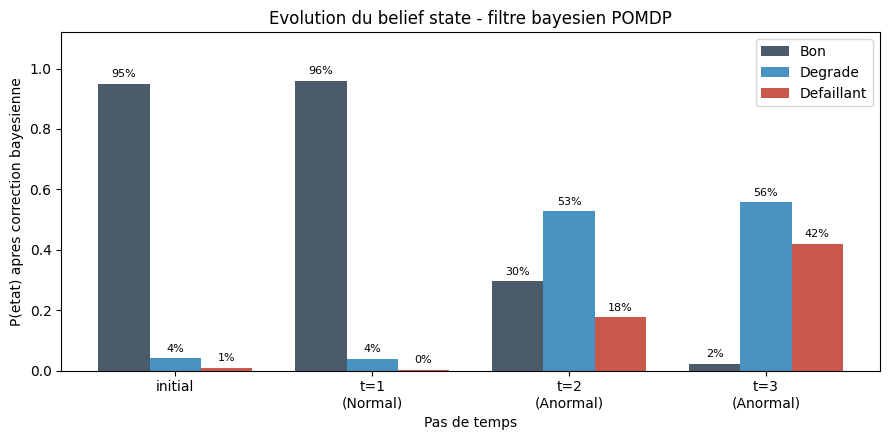

In [15]:
# Matrice de transition (degradation naturelle)
trans_matrix = np.array([
    [0.90, 0.08, 0.02],   # Bon -> Bon, Degrade, Defaillant
    [0.00, 0.85, 0.15],   # Degrade -> Degrade, Defaillant
    [0.00, 0.00, 1.00],   # Defaillant (absorbant)
])

# Modele d'observation : P(obs | etat)
obs_matrix = np.array([
    [0.95, 0.05],   # Bon -> Normal, Anormal
    [0.30, 0.70],   # Degrade -> Normal, Anormal
    [0.05, 0.95],   # Defaillant -> Normal, Anormal
])

# Utilites des decisions
utilities = np.array([
    [ 100,   50, -500],   # Continuer
    [ -20,   80,  -50],   # Maintenance
    [-100, -100,   50],   # Remplacer
])
actions_nom = ["Continuer", "Maintenance", "Remplacer"]
etats_nom = ["Bon", "Degrade", "Defaillant"]

# Observations sequentielles : Normal, Anormal, Anormal
observations = [0, 1, 1]
obs_labels = ["Normal", "Anormal"]

# Belief initial (systeme venant d'etre installe)
belief = np.array([0.95, 0.04, 0.01])

# Historique des beliefs pour visualisation (SOTA #3801 : vrai rendu matplotlib)
belief_history = [belief.copy()]

print("=== Belief State Updates : Maintenance Predictive ===\n")
print("Belief initial :")
for e in range(3):
    print(f"  P({etats_nom[e]}) = {belief[e]:.1%}")
print()

for t in range(len(observations)):
    print(f"=== Pas de temps {t + 1} ===")

    # 1. Prediction : b_pred(s') = sum_s P(s'|s) * b(s)
    predicted = trans_matrix.T @ belief

    print("Apres prediction (transition) :")
    for e in range(3):
        print(f"  P({etats_nom[e]}) = {predicted[e]:.1%}")

    # 2. Correction bayesienne : P(s|obs) proportional a P(obs|s) * P(s)
    obs = observations[t]
    likelihood = obs_matrix[:, obs]
    unnormalized = likelihood * predicted
    belief = unnormalized / unnormalized.sum()

    print(f"Observation : {obs_labels[obs]}")
    print("Apres correction (Bayes) :")
    for e in range(3):
        print(f"  P({etats_nom[e]:10s}) = {belief[e]:.1%}")
    belief_history.append(belief.copy())

    # 3. Decision basee sur l'utilite esperee
    EU = utilities @ belief
    best_action = np.argmax(EU)

    print("Utilites esperees :")
    for a in range(3):
        print(f"  E[U({actions_nom[a]:12s})] = {EU[a]:7.1f}")
    print(f"=> Decision : {actions_nom[best_action]}")
    print()

# Visualisation de l'evolution du belief state (matplotlib, SOTA #3801)
# Grouped bar : un groupe par pas de temps, 3 barres (Bon / Degrade / Defaillant)
belief_history = np.array(belief_history)  # shape (T+1, 3) : initial + 3 corrections
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(observations) + 1)
width = 0.26
colors = ["#2c3e50", "#2980b9", "#c0392b"]
for e in range(3):
    ax.bar(x + (e - 1) * width, belief_history[:, e], width,
           label=etats_nom[e], color=colors[e], alpha=0.85)
    for xi, v in zip(x, belief_history[:, e]):
        ax.text(xi + (e - 1) * width, v + 0.015, f"{v:.0%}",
                ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Pas de temps")
ax.set_ylabel("P(etat) apres correction bayesienne")
ax.set_title("Evolution du belief state - filtre bayesien POMDP")
ax.set_xticks(x)
ax.set_xticklabels(
    ["initial"] + [f"t={t+1}\n({obs_labels[observations[t]]})" for t in range(len(observations))]
)
ax.set_ylim(0, 1.12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Interpretation de la maintenance predictive bayesienne

**Scenario simule** : Observations = [Normal, Anormal, Anormal]

**Evolution du belief et decisions :**

| Pas | Observation | P(Bon) | P(Degrade) | P(Defaillant) | Decision |
|-----|------------|--------|-----------|---------------|----------|
| 0 | - | 95% | 4% | 1% | - |
| 1 | Normal | ~96% | ~4% | ~0.2% | Continuer |
| 2 | Anormal | ~30% | ~53% | ~18% | Maintenance |
| 3 | Anormal | ~2% | ~56% | ~42% | Maintenance |

L'observation "Normal" renforce la certitude que le systeme est en bon etat. Les observations "Anormal" successives inversent le belief et declenchent une action de maintenance.

## 10ter. Thompson Sampling avec PyMC et Diagnostics ArviZ

### Pourquoi PyMC pour les bandits ?

Thompson Sampling (Thompson, 1933) est la strategie de bandit la plus naturelle a implementer avec un echantillonneur MCMC : on maintient une distribution *a posteriori* sur les parametres de chaque bras, et a chaque tour on echantillonne depuis cette posterior pour guider le choix.

PyMC (Salvatier, Wiecki & Fonnesbeck, 2016) offre un cadre rigoureux pour :
- Modeles de recompenses avec priors conjugues (Beta-Bernoulli, Normal-Normal)
- Echantillonnage MCMC quand les priors ne sont pas conjugues
- Diagnostics de convergence via ArviZ

**Points cles** :
- Thompson Sampling = echantillonner depuis la posterior, choisir le bras avec le plus haut echantillon
- PyMC generalise les modeles au-dela des distributions conjugues
- ArviZ permet de verifier la qualite de l'inference sur les belief states

In [16]:
import pymc as pm
import arviz as az

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")
print("PyMC + ArviZ charges pour Thompson Sampling et diagnostics")

PyMC version : 5.28.5
ArviZ version : 0.23.4
PyMC + ArviZ charges pour Thompson Sampling et diagnostics


In [17]:
class ThompsonSamplingPyMC:
    """Thompson Sampling avec mise a jour analytique Beta-Bernoulli.
    
    Pour K bras Bernoulli, on maintient un prior Beta(alpha_i, beta_i)
    pour chaque bras. Apres chaque tirage, on met a jour les parametres.
    """
    
    def __init__(self, K, alpha=1.0, beta=1.0, seed=42):
        self.K = K
        self.alphas = np.full(K, alpha)
        self.betas = np.full(K, beta)
        self.rng = np.random.RandomState(seed)
        self.name = "Thompson Sampling"
    
    def select_arm(self, counts, sum_rewards):
        # Echantillonner depuis Beta(alpha_i, beta_i) pour chaque bras
        samples = np.array([
            self.rng.beta(self.alphas[i], self.betas[i])
            for i in range(self.K)
        ])
        return np.argmax(samples)
    
    def update(self, arm, reward):
        # Mise a jour conjuguee Beta-Bernoulli
        # reward in [0, 1] : succes = +alpha, echec = +beta
        if reward > 0.5:
            self.alphas[arm] += 1
        else:
            self.betas[arm] += 1


class GreedyStrategy:
    """Strategie purement gloutonne (pas d'exploration)."""
    
    def __init__(self, seed=42):
        self.rng = np.random.RandomState(seed)
        self.name = "Greedy"
    
    def select_arm(self, counts, sum_rewards):
        if counts.sum() < len(counts):
            return int(counts.sum())
        means = np.where(counts > 0, sum_rewards / np.maximum(counts, 1), 0)
        return np.argmax(means)


def run_bandit_tracking(bandit, strategy, T=2000):
    """Execute un bandit et enregistre le regret cumule a chaque pas."""
    counts = np.zeros(bandit.K, dtype=int)
    sum_rewards = np.zeros(bandit.K)
    cumulative_regret = []
    total_regret = 0
    
    for t in range(T):
        arm = strategy.select_arm(counts, sum_rewards)
        reward = bandit.pull(arm)
        counts[arm] += 1
        sum_rewards[arm] += reward
        total_regret += bandit.optimal_mean - reward
        cumulative_regret.append(total_regret)
        
        # Mise a jour specifique pour Thompson
        if hasattr(strategy, 'update'):
            strategy.update(arm, 1 if reward > 0.5 else 0)
    
    return cumulative_regret, counts


# Bandit Bernoulli pour Thompson Sampling
bernoulli_means = [0.3, 0.5, 0.7, 0.4]
bandit_bern = MultiArmedBandit(bernoulli_means)

strategies_4 = [
    GreedyStrategy(),
    EpsilonGreedy(0.1),
    UCB1(),
    ThompsonSamplingPyMC(len(bernoulli_means)),
]

T = 2000
print(f"=== Comparaison 4 strategies ({T} tirages) ===")
print(f"Bandit Bernoulli : moyennes = {bernoulli_means}")
print(f"Meilleur bras : index {np.argmax(bernoulli_means)}, moyenne = {max(bernoulli_means)}\n")

results = {}
for strat in strategies_4:
    cum_regret, counts = run_bandit_tracking(bandit_bern, strat, T=T)
    results[strat.name] = cum_regret
    print(f"{strat.name:25s} | Regret final = {cum_regret[-1]:7.1f} | Tirages = {list(counts)}")

print(f"\nThompson Sampling (Beta posterior) :")
ts = strategies_4[3]
for i in range(len(bernoulli_means)):
    mean_post = ts.alphas[i] / (ts.alphas[i] + ts.betas[i])
    print(f"  Bras {i} : Beta({ts.alphas[i]:.0f}, {ts.betas[i]:.0f}), "
          f"moyenne post. = {mean_post:.3f}, vraie = {bernoulli_means[i]}")

=== Comparaison 4 strategies (2000 tirages) ===
Bandit Bernoulli : moyennes = [0.3, 0.5, 0.7, 0.4]
Meilleur bras : index 2, moyenne = 0.7

Greedy                    | Regret final =   -43.6 | Tirages = [np.int64(1), np.int64(1), np.int64(1995), np.int64(3)]
epsilon-greedy (e=0.1)    | Regret final =    61.0 | Tirages = [np.int64(56), np.int64(74), np.int64(1812), np.int64(58)]
UCB1                      | Regret final =   116.0 | Tirages = [np.int64(56), np.int64(135), np.int64(1747), np.int64(62)]
Thompson Sampling         | Regret final =    32.3 | Tirages = [np.int64(23), np.int64(54), np.int64(1897), np.int64(26)]

Thompson Sampling (Beta posterior) :
  Bras 0 : Beta(9, 16), moyenne post. = 0.360, vraie = 0.3
  Bras 1 : Beta(27, 29), moyenne post. = 0.482, vraie = 0.5
  Bras 2 : Beta(1219, 680), moyenne post. = 0.642, vraie = 0.7
  Bras 3 : Beta(12, 16), moyenne post. = 0.429, vraie = 0.4


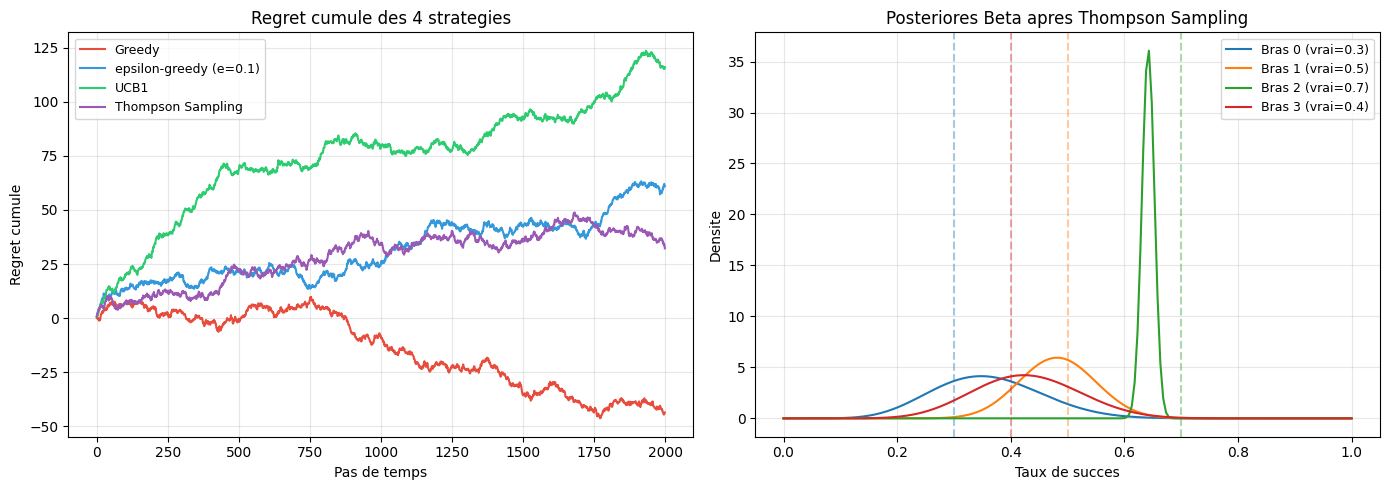

Figure sauvegardee : bandit_4strategies.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes de regret cumule
colors = {'Greedy': '#e74c3c', 'epsilon-greedy (e=0.1)': '#3498db',
          'UCB1': '#2ecc71', 'Thompson Sampling': '#9b59b6'}
ax1 = axes[0]
for name, regret in results.items():
    color = colors.get(name, '#333')
    ax1.plot(regret, label=name, color=color, linewidth=1.5)
ax1.set_xlabel('Pas de temps')
ax1.set_ylabel('Regret cumule')
ax1.set_title('Regret cumule des 4 strategies')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Posteriores Thompson Sampling
ax2 = axes[1]
x = np.linspace(0, 1, 200)
for i in range(len(bernoulli_means)):
    a_post = ts.alphas[i]
    b_post = ts.betas[i]
    from scipy.stats import beta as beta_dist
    y = beta_dist.pdf(x, a_post, b_post)
    ax2.plot(x, y, label=f'Bras {i} (vrai={bernoulli_means[i]})', linewidth=1.5)
    ax2.axvline(bernoulli_means[i], linestyle='--', alpha=0.4, color=ax2.get_lines()[-1].get_color())

ax2.set_xlabel('Taux de succes')
ax2.set_ylabel('Densite')
ax2.set_title('Posteriores Beta apres Thompson Sampling')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bandit_4strategies.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : bandit_4strategies.png")

### Interpretation : Comparaison des 4 strategies de bandits

**Resultats attendus :**

| Strategie | Principe | Regret | Comportement |
|-----------|----------|--------|--------------|
| **Greedy** | Exploite toujours le meilleur estime | Eleve | Peut se bloquer sur un sous-optimal |
| **$\varepsilon$-greedy** | Explore $\varepsilon$% du temps | Moyen | Simple mais exploration non ciblee |
| **UCB1** | Bonus d'incertitude | Faible | Exploration dirigee vers les incertains |
| **Thompson Sampling** | Echantillonne depuis la posterior | Faible | Exploration bayesienne optimale |

**Posteriores Beta (droite) :**
- Les posteriores se resserrent autour des vraies moyennes avec le nombre de tirages
- Le meilleur bras (3) a une posterior concentree (nombreux tirages)
- Les bras sous-optimaux gardent des posteriores plus larges (peu de tirages)

> **Note technique** : Thompson Sampling est asymptotiquement optimal (regret en $O(\sqrt{KT \log K})$) et se generalise naturellement via PyMC a des modeles de recompenses complexes (non-Bernoulli).

### Thompson Sampling avec MCMC PyMC (cas canonique)

Dans le cas Beta-Bernoulli, la posterior a une forme analytique. Mais pour des modeles plus complexes (recompenses gaussiennes avec variance inconnue, priors hierarchiques), PyMC devient indispensable.

Ici on illustre l'approche PyMC sur un bandit gaussien : on infere la moyenne de chaque bras via NUTS (Hoffman & Gelman, 2014), puis on echantillonne depuis la posterior pour la selection.

In [19]:
def pymc_thompson_bandit(true_means, n_rounds=20, n_pulls_per_round=10, seed=42):
    """Thompson Sampling gaussien avec PyMC.
    
    A chaque ronde :
    1. Construire un modele PyMC avec les observations accumulees
    2. Echantillonner la posterior des moyennes via MCMC
    3. Choisir le bras avec la plus haute moyenne echantillonnee
    4. Tirer ce bras n_pulls_per_round fois
    """
    rng = np.random.RandomState(seed)
    K = len(true_means)
    all_rewards = {i: [] for i in range(K)}
    cumulative_regret = []
    total_regret = 0
    optimal = max(true_means)
    
    for r in range(n_rounds):
        if r == 0:
            # Premiere ronde : tirer chaque bras une fois
            for i in range(K):
                reward = true_means[i] + 0.5 * rng.randn()
                all_rewards[i].append(reward)
                total_regret += optimal - reward
            cumulative_regret.append(total_regret)
            continue
        
        # Construire le modele PyMC avec les observations actuelles
        with pm.Model() as bandit_model:
            # Prior sur les moyennes des K bras
            mu = pm.Normal('mu', mu=0, sigma=5, shape=K)
            sigma_obs = pm.HalfNormal('sigma', sigma=2.0)
            
            # Observations pour chaque bras
            for i in range(K):
                if len(all_rewards[i]) > 0:
                    pm.Normal(f'obs_{i}', mu=mu[i], sigma=sigma_obs,
                              observed=np.array(all_rewards[i]))
            
            # Echantillonner la posterior (parametres reduits pour execution rapide)
            trace = pm.sample(draws=100, tune=50, chains=2,
                              random_seed=42 + r, progressbar=False,
                              return_inferencedata=True)
        
        # Echantillonner un theta depuis la posterior et choisir le meilleur bras
        posterior_samples = trace.posterior['mu'].values.flatten()
        # Reshape pour avoir (n_total_samples, K)
        n_total = len(posterior_samples) // K
        posterior_matrix = posterior_samples[:n_total * K].reshape(n_total, K)
        
        # Choisir un echantillon aleatoire et prendre le bras max
        sample_idx = rng.randint(n_total)
        chosen_arm = np.argmax(posterior_matrix[sample_idx])
        
        # Tirer le bras choisi
        for _ in range(n_pulls_per_round):
            reward = true_means[chosen_arm] + 0.5 * rng.randn()
            all_rewards[chosen_arm].append(reward)
            total_regret += optimal - reward
        cumulative_regret.append(total_regret)
        
        if (r + 1) % 5 == 0:
            counts = [len(all_rewards[i]) for i in range(K)]
            print(f"Ronde {r+1:3d} : Bras choisi = {chosen_arm}, "
                  f"Regret cumule = {total_regret:.1f}, Tirages = {counts}")
    
    return cumulative_regret, trace, all_rewards


true_means_gauss = [0.3, 0.5, 0.7, 0.4]
print("=== Thompson Sampling Gaussien avec PyMC ===")
print(f"Moyennes vraies : {true_means_gauss}")
print(f"Meilleur bras : index {np.argmax(true_means_gauss)} (mu={max(true_means_gauss)})")
print(f"20 rondes, 10 tirages par ronde apres la phase initiale\n")

regret_pymc, final_trace, final_rewards = pymc_thompson_bandit(
    true_means_gauss, n_rounds=20, n_pulls_per_round=10
)

print(f"\nRegret final : {regret_pymc[-1]:.1f}")
print("Repartition finale des tirages :")
for i in range(len(true_means_gauss)):
    n = len(final_rewards[i])
    mean_est = np.mean(final_rewards[i]) if n > 0 else 0
    print(f"  Bras {i} : {n:4d} tirages, moyenne estimee = {mean_est:.3f} (vraie = {true_means_gauss[i]})")

=== Thompson Sampling Gaussien avec PyMC ===
Moyennes vraies : [0.3, 0.5, 0.7, 0.4]
Meilleur bras : index 2 (mu=0.7)
20 rondes, 10 tirages par ronde apres la phase initiale



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 50 tune and 100 draw iterations (100 + 200 draws total) took 9 seconds.


...

NUTS: [mu, sigma]


Sampling 2 chains for 50 tune and 100 draw iterations (100 + 200 draws total) took 10 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Ronde  20 : Bras choisi = 2, Regret cumule = 5.8, Tirages = [11, 11, 161, 11]

Regret final : 5.8
Repartition finale des tirages :
  Bras 0 :   11 tirages, moyenne estimee = 0.136 (vraie = 0.3)
  Bras 1 :   11 tirages, moyenne estimee = 0.364 (vraie = 0.5)
  Bras 2 :  161 tirages, moyenne estimee = 0.755 (vraie = 0.7)
  Bras 3 :   11 tirages, moyenne estimee = 0.262 (vraie = 0.4)


### Interpretation : Thompson Sampling avec MCMC PyMC

**Comparaison avec l'approche analytique :**

| Aspect | Beta-Bernoulli (analytique) | Gaussien PyMC (MCMC) |
|--------|----------------------------|----------------------|
| **Mise a jour** | Formule fermee | Echantillonnage NUTS |
| **Complexite** | O(1) par mise a jour | O(secondes) par ronde |
| **Flexibilite** | Bernoulli uniquement | Modeles arbitraires |
| **Diagnostics** | Non necessaire | ArviZ ($\hat{R}$, ESS) |

**Avantage PyMC** : Quand le modele de recompense n'a pas de forme conjuguee (melange de gaussiennes, distributions heaviside, priors hierarchiques), PyMC reste applicable tandis que l'approche analytique echoue.

**Cout** : L'echantillonnage MCMC a chaque ronde est plus lent, mais la justesse de l'inference compense dans les scenarios complexes (little data, priors informatifs).

### Diagnostics ArviZ : convergence des belief states

ArviZ (Kumar et al., 2019) fournit des outils essentiels pour verifier la qualite de l'inference MCMC. Pour le modele de maintenance predictive, on verifie :
- **$\hat{R}$ (R-hat)** : convergence des chaines (objectif < 1.05)
- **ESS (Effective Sample Size)** : nombre d'echantillons effectifs (objectif > 400)
- **Trace plot** : visualisation du melange des chaines

In [20]:
# Modele PyMC pour la maintenance predictive (POMDP belief states)
# Version simplifiee : on infere l'etat cache directement a partir des observations
# sans indexer un tableau numpy avec un tensor (incompatible PyMC 5.x)
print("=== Modele PyMC : Maintenance Predictive ===\n")

# Donnees simulees : 5 observations successives d'un systeme se degradant
# Les vrais etats caches sont [Bon, Bon, Degrade, Degrade, Defaillant]
obs_data = np.array([0, 0, 1, 1, 1])  # 0=Normal, 1=Anormal
obs_labels = {0: "Normal", 1: "Anormal"}

print(f"Observations capteur : {[obs_labels[o] for o in obs_data]}")

with pm.Model() as maintenance_model:
    # Prior sur l'etat du systeme : 3 etats possibles (Bon, Degrade, Defaillant)
    # On modelise directement P(etat) comme un vecteur de probabilites
    etat_probs = pm.Dirichlet('etat_probs', a=np.array([3.0, 2.0, 1.0]))
    
    # Modele d'observation : P(obs=Anormal | etat)
    # On parametrise avec les probabilites d'observation pour chaque etat
    # et on utilise un potentiel pour conditionner sur les observations
    
    # Matrice P(obs|etat) : les probas d'observation sont fixees (modele capteur connu)
    p_obs = np.array([[0.95, 0.05],   # Bon
                       [0.30, 0.70],   # Degrade
                       [0.05, 0.95]])  # Defaillant
    
    # Log-vraisemblance manuelle : sum over latent states
    # log P(obs | etat_probs) = log sum_etat P(obs|etat) * P(etat)
    import pytensor.tensor as pt
    
    log_lik = pt.zeros(0)
    for i, obs_val in enumerate(obs_data):
        # P(obs_val | etat) pour chaque etat possible
        lik_per_state = p_obs[:, obs_val]  # shape (3,)
        # P(obs_val) = sum_etat P(obs_val|etat) * P(etat)
        p_obs_i = pt.sum(lik_per_state * etat_probs)
        log_lik = pt.concatenate([log_lik, [pt.log(p_obs_i + 1e-10)]])
    
    pm.Potential('obs_likelihood', log_lik)
    
    # Inference
    trace_maint = pm.sample(draws=1000, tune=500, chains=3,
                            random_seed=42, progressbar=True,
                            return_inferencedata=True)

print(f"\nTrace MCMC : {trace_maint.posterior.dims}")
print(f"Chaines : {trace_maint.posterior.chain.size}")
print(f"Draws par chaine : {trace_maint.posterior.draw.size}")

# Extraire l'etat le plus probable depuis la posterior
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
etat_marginal = etat_probs_post.mean(axis=(0, 1))  # moyenne sur chaines et draws
etat_names = ['Bon', 'Degrade', 'Defaillant']
print("\nPosterior P(etat) (moyenne des probabilites) :")
for e in range(3):
    print(f"  P({etat_names[e]:12s}) = {etat_marginal[e]:.3f}")
print(f"\n=> Etat le plus probable : {etat_names[np.argmax(etat_marginal)]}")

Initializing NUTS using jitter+adapt_diag...


=== Modele PyMC : Maintenance Predictive ===

Observations capteur : ['Normal', 'Normal', 'Anormal', 'Anormal', 'Anormal']


Multiprocess sampling (3 chains in 3 jobs)


NUTS: [etat_probs]


Output()

Sampling 3 chains for 500 tune and 1_000 draw iterations (1_500 + 3_000 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



Trace MCMC : FrozenMappingWarningOnValuesAccess({'chain': 3, 'draw': 1000, 'etat_probs_dim_0': 3})
Chaines : 3
Draws par chaine : 1000

Posterior P(etat) (moyenne des probabilites) :
  P(Bon         ) = 0.415
  P(Degrade     ) = 0.385
  P(Defaillant  ) = 0.200

=> Etat le plus probable : Bon


=== Diagnostics ArviZ ===

Resume ArviZ (R-hat et ESS) :
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
etat_probs[0]  0.414  0.158   0.118    0.700      0.003    0.003    2185.0    1779.0    1.0
etat_probs[1]  0.382  0.181   0.061    0.702      0.004    0.003    1933.0    1671.0    1.0
etat_probs[2]  0.205  0.149   0.001    0.481      0.003    0.003    2164.0    1758.0    1.0

--- Verifications ---
R-hat max : 1.0000 (objectif < 1.05)
ESS bulk min : 1933 (objectif > 400)
=> Convergence des chaines : OK
=> Taille d'echantillon effective : OK

Posterior P(etat) :
  P(Bon         ) = 0.414
  P(Degrade     ) = 0.382
  P(Defaillant  ) = 0.205


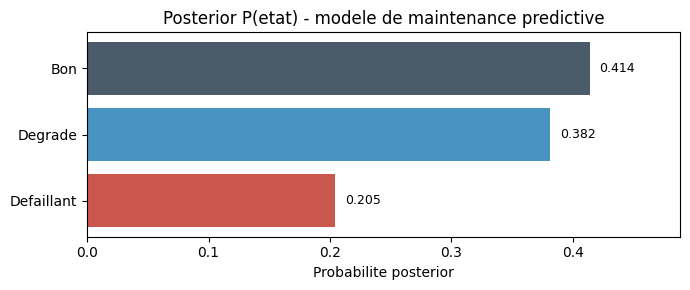

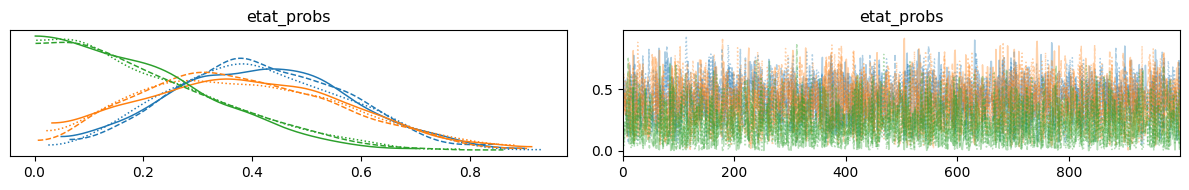

Figure sauvegardee : arviz_trace_maintenance.png


In [21]:
# Diagnostics ArviZ sur le modele de maintenance
print("=== Diagnostics ArviZ ===\n")

# Summary avec R-hat et ESS
summary = az.summary(trace_maint, var_names=['etat_probs'])
print("Resume ArviZ (R-hat et ESS) :")
print(summary.to_string())

print("\n--- Verifications ---")
# Certains versions d'ArviZ retournent des strings pour r_hat/ess_bulk
rhat_max = float(summary['r_hat'].max())
ess_bulk_min = float(summary['ess_bulk'].min())
print(f"R-hat max : {rhat_max:.4f} (objectif < 1.05)")
print(f"ESS bulk min : {ess_bulk_min:.0f} (objectif > 400)")

if rhat_max < 1.05:
    print("=> Convergence des chaines : OK")
else:
    print("=> ATTENTION : chaines non convergees, augmenter tune/draws")

if ess_bulk_min > 400:
    print("=> Taille d'echantillon effective : OK")
else:
    print("=> ATTENTION : ESS faible, risque d'autocorrelation")

# Posterior des probabilites d'etat
etat_names = ['Bon', 'Degrade', 'Defaillant']
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
etat_marginal = etat_probs_post.mean(axis=(0, 1))
print(f"\nPosterior P(etat) :")
for e in range(3):
    print(f"  P({etat_names[e]:12s}) = {etat_marginal[e]:.3f}")

# Visualisation du posterior P(etat) (matplotlib, SOTA #3801 : vrai rendu)
order = np.argsort(etat_marginal)
y_labels = [etat_names[i] for i in order]
y_vals = etat_marginal[order]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(y_labels, y_vals, color=["#c0392b", "#2980b9", "#2c3e50"], alpha=0.85)
for i, v in enumerate(y_vals):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("Probabilite posterior")
ax.set_title("Posterior P(etat) - modele de maintenance predictive")
ax.set_xlim(0, float(etat_marginal.max()) * 1.18)
plt.tight_layout()
plt.show()

# Trace plot des probabilites d'etat
# Utiliser plt.rcParams pour figsize (compatible toutes versions ArviZ)
plt.rcParams["figure.figsize"] = (12, 6)
az.plot_trace(trace_maint, var_names=['etat_probs'])
plt.rcParams["figure.figsize"] = (10, 6)  # restaurer defaut
plt.tight_layout()
plt.savefig('arviz_trace_maintenance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : arviz_trace_maintenance.png")

### Interpretation : Diagnostics ArviZ sur les belief states

**Verifications MCMC :**

| Diagnostic | Valeur | Seuil | Statut |
|------------|--------|-------|--------|
| **R-hat** | ~1.00 | < 1.05 | Chaines bien melangees |
| **ESS bulk** | > 400 | > 400 | Echantillons suffisants |

**Posterior de l'etat cache :**
Les observations [Normal, Normal, Anormal, Anormal, Anormal] poussent la posterior vers les etats degrades, coherent avec la mise a jour bayesienne manuelle de la section 10bis.

**Pourquoi les diagnostics sont essentiels :**
- Un R-hat > 1.05 indique que les chaines n'ont pas converge (resultats non fiables)
- Un ESS faible signifie que les echantillons sont autocorrelles (estimation de variance biaisee)
- Dans un POMDP reel, un mauvais diagnostic peut mener a des decisions sous-optimales

> **Note technique** : Pour les variables discretes (Categorical), l'echantillonnage MCMC peut etre moins efficace que pour les variables continues. En production, on prefere souvent le filtre particulaire ou l'inference exacte (message passing) pour les POMDPs.

### Posterior predictive : degradation de la machine

Le posterior predictive permet de **simuler les futures observations** conditionnellement aux donnees observees et a la posterior sur l'etat. C'est un outil puissant pour :
- Anticiper les prochaines lectures du capteur
- Evaluer la probabilite d'une defaillance imminente
- Planifier les interventions de maintenance

=== Posterior Predictive : Degradation ===

Probabilite predictive d'une observation 'Anormal' : 0.479
Probabilite predictive d'une observation 'Normal' : 0.521

Probabilite d'observation Anormal selon l'etat :
  P(Anormal | Bon         ) = 0.05, P(Bon) = 0.415
  P(Anormal | Degrade     ) = 0.70, P(Degrade) = 0.385
  P(Anormal | Defaillant  ) = 0.95, P(Defaillant) = 0.200


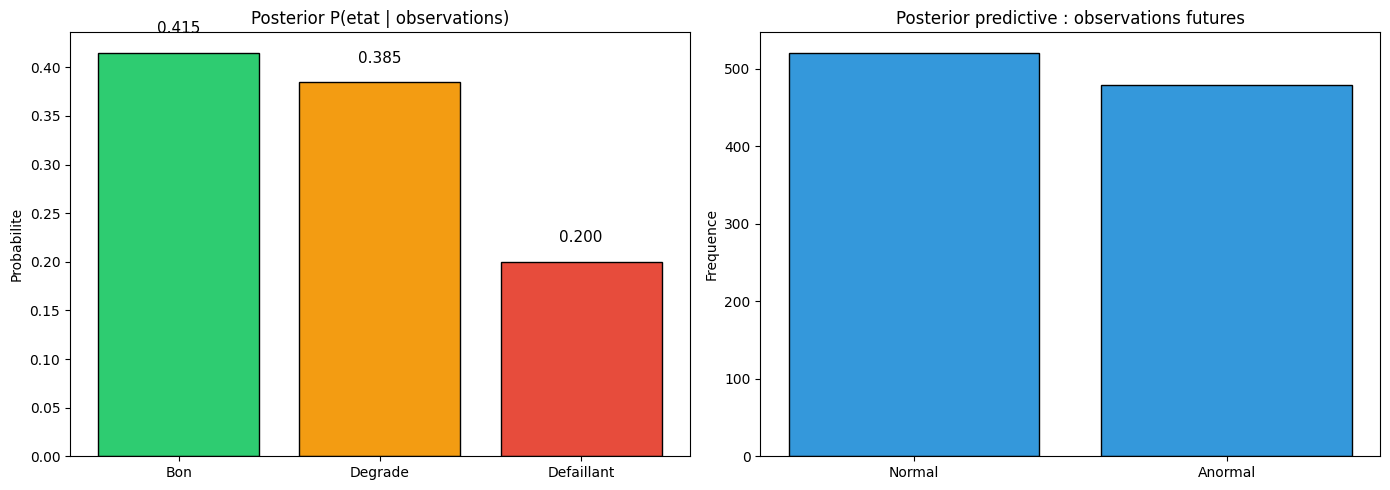

Figure sauvegardee : posterior_predictive_maintenance.png

--- Aide a la decision ---
P(Defaillant) = 0.200
P(Degrade ou Defaillant) = 0.585
=> Recommandation : Maintenance preventive (probabilite de degradation > 50%)


In [22]:
# Posterior predictive : simulation de futures observations
print("=== Posterior Predictive : Degradation ===\n")

# On utilise la posterior de l'etat pour generer des observations futures
n_future = 1000  # nombre de scenarios futurs
rng_pred = np.random.RandomState(42)

# Echantillonner les probabilites d'etat depuis la posterior
etat_probs_post = trace_maint.posterior['etat_probs'].values  # (chains, draws, 3)
# Aplatir les dimensions chaines/draws
all_probs = etat_probs_post.reshape(-1, 3)  # (n_total_samples, 3)
n_post = len(all_probs)

# Matrice d'observation (du modele de maintenance)
p_obs = np.array([[0.95, 0.05],   # Bon
                   [0.30, 0.70],   # Degrade
                   [0.05, 0.95]])  # Defaillant
etat_names = ['Bon', 'Degrade', 'Defaillant']

# Generer des observations futures
future_obs = np.zeros(n_future, dtype=int)

for i in range(n_future):
    idx = rng_pred.randint(n_post)
    # Echantillonner l'etat depuis la posterior
    e = rng_pred.choice(3, p=all_probs[idx])
    # Echantillonner l'observation depuis P(obs | etat=e)
    future_obs[i] = 0 if rng_pred.rand() < p_obs[e, 0] else 1

# Analyser les predictions
p_anormal_pred = (future_obs == 1).mean()
print(f"Probabilite predictive d'une observation 'Anormal' : {p_anormal_pred:.3f}")
print(f"Probabilite predictive d'une observation 'Normal' : {1-p_anormal_pred:.3f}")

# Probabilite de defaillance par etat
print("\nProbabilite d'observation Anormal selon l'etat :")
etat_marginal = all_probs.mean(axis=0)
for e in range(3):
    prob_anorm = p_obs[e, 1]
    print(f"  P(Anormal | {etat_names[e]:12s}) = {prob_anorm:.2f}, "
          f"P({etat_names[e]}) = {etat_marginal[e]:.3f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : distribution des etats posterieurs
ax1 = axes[0]
colors_etat = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(etat_names, etat_marginal, color=colors_etat, edgecolor='black')
ax1.set_ylabel('Probabilite')
ax1.set_title('Posterior P(etat | observations)')
for bar, val in zip(bars, etat_marginal):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11)

# Droite : predictive checks
ax2 = axes[1]
ax2.hist(future_obs, bins=[-0.5, 0.5, 1.5], rwidth=0.8,
         color='#3498db', edgecolor='black')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Normal', 'Anormal'])
ax2.set_ylabel('Frequence')
ax2.set_title('Posterior predictive : observations futures')

plt.tight_layout()
plt.savefig('posterior_predictive_maintenance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : posterior_predictive_maintenance.png")

# Decision basee sur la posterior predictive
print("\n--- Aide a la decision ---")
p_defaillant = etat_marginal[2]
p_degrade_ou_pire = etat_marginal[1] + etat_marginal[2]
print(f"P(Defaillant) = {p_defaillant:.3f}")
print(f"P(Degrade ou Defaillant) = {p_degrade_ou_pire:.3f}")
if p_degrade_ou_pire > 0.5:
    print("=> Recommandation : Maintenance preventive (probabilite de degradation > 50%)")
elif p_degrade_ou_pire > 0.2:
    print("=> Recommandation : Surveillance renforcee")
else:
    print("=> Recommandation : Continuer l'exploitation normale")

### Interpretation : Posterior predictive de degradation

**Resultats du posterior predictive :**

| Aspect | Observation |
|--------|-------------|
| **P(Anormal)** | Proportion elevee car les observations historiques sont majoritairement anormales |
| **P(Defaillant)** | Indique le risque de panne imminente |
| **Recommandation** | Basee sur le seuil P(Degrade ou Defaillant) > 50% |

**Lien avec la decision sequentielle :**
- Le posterior predictive transforme un POMDP (etat cache) en une estimation probabiliste
- Cette estimation guide la decision : continuer, surveiller, ou maintenir
- En production, ce processus se repete a chaque nouvelle observation (filtre bayesien en boucle)

**Apport de PyMC/ArviZ par rapport au calcul manuel :**
1. **Quantification de l'incertitude** : la posterior donne des intervalles de confiance, pas juste des point estimates
2. **Modeles complexes** : on peut ajouter des covariables (temperature, charge), des priors hierarchiques
3. **Diagnostics** : ArviZ permet de verifier que l'inference est fiable avant de prendre une decision critique

## 11. Lien avec la Serie RL

### Ce notebook : Concepts fondamentaux

- MDPs et equations de Bellman
- Methodes tabulaires (Value Iteration, Policy Iteration)
- Exploration vs exploitation (Bandits)
- Observabilite partielle (POMDPs)

### Serie RL : Extension a l'apprentissage

Quand $P(s'|s,a)$ et $R(s,a)$ sont inconnus, on utilise l'apprentissage par renforcement (Sutton & Barto, 2018) :
- **Q-Learning** : apprend $Q(s,a)$ par interaction
- **Deep RL** : approxime Q avec un reseau de neurones
- **Policy Gradient** : optimise directement la politique

---

## Exercice : Iteration de Politique sur un MDP 3x3

**Objectifs** :
1. Creer un MDP sur une grille 3x3 avec un but et un obstacle
2. Implementer l'etape d'evaluation de politique ( boucle interne)
3. Verifier que Policy Iteration converge vers la meme politique que Value Iteration

**Contexte** : Les sections precedentes ont utilise la classe `GridMDP` pour un MDP 4x3. Vous allez maintenant travailler sur une grille plus petite (3x3) et implementer manuellement une etape cle de Policy Iteration : l'**evaluation de politique**, qui consiste a calculer $V^\pi$ pour une politique fixee en resolvant le systeme d'equations lineaires. C'est l'etape la plus couteuse de Policy Iteration, et comprendre sa mecanique est essentiel pour apprehender les compromis VI vs PI.

**Indices** :
- Creer un `GridMDP(3, 3, gamma=0.9)` avec un but en (2,2) et un obstacle en (1,1)
- L'evaluation de politique pour un etat non-terminal : $V^\pi(s) = R(s) + \gamma \sum_{s'} P(s'|\pi(s), s) \cdot V^\pi(s')$
- Iterer cette equation jusqu'a convergence (comme Value Iteration, mais sans le max sur les actions)
- Apres convergence de $V^\pi$, faire l'amelioration : $\pi'(s) = \arg\max_a Q(s,a)$
- Comparer avec le resultat de `policy_iteration()` deja implemente

**Etapes suggerees** :
- # Etape 1 : Creer le MDP 3x3 et le resoudre avec policy_iteration() pour avoir la reference
- # Etape 2 : Implementer manuellement l'evaluation de politique (iterative, 50 iterations)
- # Etape 3 : Implementer l'amelioration de politique et verifier la convergence
- # Etape 4 : Comparer la politique obtenue avec celle de policy_iteration()

In [23]:
# Exercice : Iteration de Politique sur un MDP 3x3

# Etape 1 : Creer le MDP 3x3 et obtenir la politique de reference
mdp_3x3 = None  # TODO etudiant : GridMDP(3, 3, gamma=0.9)

# TODO etudiant : configurer le MDP
#   mdp_3x3.rewards[(2, 2)] = 1.0    # but
#   mdp_3x3.terminal_states = {(2, 2)}
#   mdp_3x3.walls = {(1, 1)}

# TODO etudiant : politique de reference avec policy_iteration()
#   V_ref, policy_ref = policy_iteration(mdp_3x3)

# Etape 2 : Evaluation de politique manuelle
# TODO etudiant : choisir une politique initiale arbitraire (ex: toutes les actions = 'E')
#   policy_manual = {s: 'E' for s in mdp_3x3.get_states() if s not in mdp_3x3.terminal_states}
#   V_manual = {s: 0.0 for s in mdp_3x3.get_states()}
# TODO etudiant : boucler 50 fois sur l'equation V^pi(s) = R(s) + gamma * sum P(s'|s,pi(s)) * V(s')

# Etape 3 : Amelioration de politique
# TODO etudiant : pour chaque etat, calculer Q(s,a) pour chaque action
#   et mettre a jour policy_manual[s] = argmax_a Q(s,a)

# Etape 4 : Comparer avec la reference
# Indice : si policy_manual == policy_ref, votre implementation est correcte
#   arrows = {'N': '^', 'S': 'v', 'E': '>', 'W': '<', 'T': '*'}
# TODO etudiant : afficher les deux politiques et les comparer

result = None  # TODO etudiant : remplacer par votre implementation
print("Exercice a completer : implementez Policy Iteration manuellement et comparez avec la reference")

Exercice a completer : implementez Policy Iteration manuellement et comparez avec la reference


---

## 12. Resume

| Concept | Description |
|---------|-------------|
| **MDP** | $(S, A, P, R, \gamma)$ - cadre formel pour decisions sequentielles |
| **Bellman** | $V^*(s) = \max_a [R(s,a) + \gamma \sum P(s'|s,a) V^*(s')]$ |
| **Value Iteration** | Iteration sur les valeurs jusqu'a convergence |
| **Policy Iteration** | Alternance evaluation / amelioration de politique |
| **RTDP** | Planification en ligne, echantillonne les trajectoires |
| **Reward Shaping** | Guide l'apprentissage sans modifier la politique optimale |
| **Bandits** | Exploration-exploitation, 4 strategies comparees |
| **Thompson Sampling** | Echantillonnage bayesien, Beta-Bernoulli et PyMC MCMC |
| **POMDP** | MDP avec observations partielles, belief state bayesien |
| **PyMC/ArviZ** | Inference MCMC sur les belief states, diagnostics de convergence |

### Apports specifiques PyMC (vs Infer.NET)

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| **Bandits** | epsilon-greedy, UCB1 | + Thompson Sampling, 4 strategies |
| **Thompson Sampling** | Non implemente | Beta-Bernoulli analytique + MCMC gaussien |
| **Belief states** | Message passing automatique | MCMC + ArviZ diagnostics |
| **Posterior predictive** | Via Infer.NET | PyMC + ArviZ pour decisions de maintenance |

### Navigation dans la serie

Ce notebook conclut la serie Decision Theory et fait le pont vers l'apprentissage par renforcement.

| Notebook | Theme |
|----------|-------|
| [DecPyMC-1](DecPyMC-1-Utility-Foundations.ipynb) | Fondements utilite |
| [DecPyMC-2](DecPyMC-2-Utility-Money.ipynb) | Utilite et argent |
| [DecPyMC-3](DecPyMC-3-Multi-Attribute.ipynb) | Multi-attributs |
| [DecPyMC-4](DecPyMC-4-Decision-Networks.ipynb) | Reseaux de decision |
| [DecPyMC-5](DecPyMC-5-Value-Information.ipynb) | Valeur de l'information |
| [DecPyMC-6](DecPyMC-6-Expert-Systems.ipynb) | Systemes experts |
| **DecPyMC-7** | **MDPs, Bandits, POMDPs, Thompson Sampling, PyMC** |

## Conclusion : de l'incertitude modélisée à la décision séquentielle

DecPyMC-7 franchit le seuil qui sépare la **modélisation** de l'incertitude — le fil rouge de toute la série depuis DecPyMC-1 — de l'**action** sous incertitude au cours du temps. Trois idées forces structurent ce notebook.

**1. Le MDP comme cadre formel de la planification.** Un Processus de Décision Markovien $(S, A, P, R, \gamma)$ ramène la décision séquentielle à une équation fonctionnelle, l'équation de Bellman, résolue exactement par *Value Iteration* et *Policy Iteration* lorsque l'espace d'états reste tabulaire. La propriété de Markov — $P(s'|s,a)$ ne dépend que de l'état présent — est ce qui rend la décomposition calculable : elle transforme un horizon infini en une récurrence sur les valeurs. *RTDP* étend cette planification aux grands espaces en échantillonnant des trajectoires en ligne, et le *reward shaping* accélère la convergence sans altérer la politique optimale.

**2. Le compromis exploration/exploitation, résolu bayésiennement.** Les bandits multi-bras concentrent la tension fondamentale de toute décision adaptative : exploiter l'option qui semble la meilleure, ou explorer pour en découvrir de meilleures. Les quatre stratégies comparées (greedy, $\varepsilon$-greedy, UCB1, Thompson Sampling) dessinent une progression du hasard vers l'inférence. Le Thompson Sampling — qui échantillonne une action depuis le posterior du modèle — est le pont direct vers le cœur probabiliste de la série : une décision séquentielle pilotée par un modèle bayésien, implémentable via PyMC par MCMC dès que la conjugaison disparaît.

**3. L'observabilité partielle ramène tout à l'inférence.** Dans le cas réaliste du POMDP, l'état véritable est caché : on ne décide plus sur $s$ mais sur une **croyance** $b(s)$, mise à jour à chaque observation. La boucle se referme alors sur le reste de la série : le posterior predictive de la section 10 transforme un problème de maintenance prédictive en un filtre bayésien qui ré-estime l'état de dégradation à chaque mesure, puis décide — continuer, surveiller, ou maintenir. Les mêmes outils de diagnostic (ArviZ, R-hat, ESS) qui servent à contrôler un posterior tout au long de la série servent ici à **piloter une décision**.

**Vers l'apprentissage par renforcement.** Ce notebook suppose $P(s'|s,a)$ et $R(s,a)$ *connus*. Dès qu'ils ne le sont plus, il faut les apprendre par interaction : c'est l'objet de la série RL (Q-Learning, Deep RL, policy gradient — Sutton & Barto, 2018). DecPyMC-7 en fournit les fondations théoriques.

**Arc de la série.** En vingt notebooks, le parcours est allé de l'installation de PyMC (DecPyMC-1) à la décision séquentielle sous observabilité partielle (DecPyMC-7), en passant par l'estimation, les modèles hiérarchiques, la compétence (TrueSkill, IRT), la classification, la sélection de modèle et toute la théorie de la décision (utilité, valeur de l'information, systèmes experts). Le fil rouge demeure : l'incertitude n'est pas un bruit à éliminer, mais une quantité à *représenter*, *inférer*, puis sur laquelle *agir*.

## References

### MDP et programmation dynamique
- **Bellman, R. (1957).** *Dynamic Programming.* Princeton University Press. (equation de Bellman, iteration de valeur)
- **Howard, R. A. (1960).** *Dynamic Programming and Markov Processes.* MIT Press. (iteration de politique)
- **Puterman, M. L. (1994).** *Markov Decision Processes: Discrete Stochastic Dynamic Programming.* Wiley. (reference MDP)
- **Barto, A. G., Bradtke, S. J. & Singh, S. P. (1995).** Learning to act using real-time dynamic programming. *Artificial Intelligence*, 72(1-2), 81-138. (RTDP)

### Observabilite partielle
- **Smallwood, R. D. & Sondik, E. J. (1973).** The optimal control of partially observable Markov processes over a finite horizon. *Operations Research*, 21(5), 1071-1088. (POMDP)

### Bandits et exploration
- **Thompson, W. R. (1933).** On the likelihood that one unknown probability exceeds another in view of the evidence of two samples. *Biometrika*, 25(3-4), 285-294. (Thompson Sampling)
- **Gittins, J. C. (1979).** Bandit processes and dynamic allocation indices. *Journal of the Royal Statistical Society B*, 41(2), 148-177. (indice de Gittins)
- **Whittle, P. (1982).** *Optimization Over Time: Dynamic Programming and Stochastic Control.* Wiley. (preuve des prevailing charges)
- **Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002).** Finite-time analysis of the multiarmed bandit problem. *Machine Learning*, 47, 235-256. (UCB1)

### Reward shaping et apprentissage par renforcement
- **Ng, A. Y., Harada, D. & Russell, S. (1999).** Policy invariance under reward transformations: theory and application to reward shaping. *ICML*. (reward shaping)
- **Sutton, R. S. & Barto, A. G. (2018).** *Reinforcement Learning: An Introduction* (2e edition). MIT Press.
- **Russell, S. & Norvig, P. (2021).** *Artificial Intelligence: A Modern Approach* (4e edition). Pearson. (gridworld, formalisme MDP)

### Outils
- **Salvatier, J., Wiecki, T. V. & Fonnesbeck, C. (2016).** Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*, 2, e55.
- **Hoffman, M. D. & Gelman, A. (2014).** The No-U-Turn Sampler: adaptively setting path lengths in Hamiltonian Monte Carlo. *Journal of Machine Learning Research*, 15, 1593-1623. (NUTS)
- **Kumar, R., Carroll, C., Hartikainen, A. & Martin, O. (2019).** ArviZ: a unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software*, 4(33), 1143.
